# ECG-Derived Heart Rate Variability Analysis for Stress Detection Using NeuroPype
#### Sabin Poudel, Student ID: 113034860, Course : Human Information Processing 





This project investigates whether ECG-derived heart rate variability can distinguish baseline and stress states during human information processing. Stressful cognitive and emotional conditions activate the autonomic nervous system, especially sympathetic activity, while often reducing parasympathetic or vagal regulation. These autonomic changes are reflected in the timing between heartbeats. Therefore, ECG-derived heart rate variability provides a useful physiological index for studying autonomic reactions to stress.

The project uses the WESAD dataset, a public wearable physiology dataset designed for stress and affect detection. The main signal used in this project is chest ECG recorded from the RespiBAN device at 700 Hz. The analysis compares baseline and stress segments. The core hypothesis is that stress will increase heart rate and reduce HRV compared with baseline. Specifically, stress is expected to reduce time-domain HRV metrics such as SDNN, RMSSD, SDSD, NN50, and pNN50.

The project includes both offline and pipeline-based analysis. In Jupyter Notebook(herein), the ECG is extracted, filtered, visually inspected, artifact-marked, and converted into HRV features. Figures are generated, including raw and filtered ECG time-series plots, PSD before/after filtering, artifact-marked ECG, R-peak visualization, paired baseline-vs-stress HRV plots, and latent-space visualizations using PCA, t-SNE, and UMAP. A simple JAX logistic-regression model is also used to test whether extracted HRV features contain stress-relevant information.

Finally, the preprocessed ECG is streamed into NeuroPype using Lab Streaming Layer. The NeuroPype pipeline demonstrates signal input, filtering, R-peak detection, heart-rate extraction, HRV feature extraction, and final computational output.

## Workflow

1. Load WESAD `.pkl` files.
2. Extract chest ECG.
3. Keep only baseline and stress labels.
4. Convert data to CSV.
5. Filter ECG.
6. Visualize raw and filtered ECG.
7. Generate PSD before/after filtering.
8. Mark artifacts.
9. Detect R-peaks.
10. Extract HRV features.
11. Compare baseline vs stress.
12. Use JAX for simple stress classification.
13. Visualize HRV feature space using PCA, t-SNE, and UMAP.
14. Export clean ECG for NeuroPype.

In [1]:
import sys
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import neurokit2 as nk
from tqdm.notebook import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import umap

import jax
import jax.numpy as jnp
from jax import jit, grad

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 120



In [2]:
from pathlib import Path

# Main project folder 
PROJECT_DIR = Path("/home/xzkhu/Documents/ecg-hrv-wesad-neuropype")

# Raw WESAD dataset folder
RAW_DIR = PROJECT_DIR / "data" / "raw" / "WESAD"

# Processed data folders
RAW_CSV_DIR = PROJECT_DIR / "data" / "processed" / "raw_csv"
FILTERED_CSV_DIR = PROJECT_DIR / "data" / "processed" / "filtered_csv"
CLEAN_CSV_DIR = PROJECT_DIR / "data" / "processed" / "clean_csv"
NEURO_INPUT_DIR = PROJECT_DIR / "data" / "processed" / "neuro_input"

# Features and results
FEATURE_DIR = PROJECT_DIR / "data" / "features"
RESULT_DIR = PROJECT_DIR / "results"

# Figure folders
FIG_RAW_DIR = PROJECT_DIR / "figures" / "raw"
FIG_FILTERED_DIR = PROJECT_DIR / "figures" / "filtered"
FIG_PSD_DIR = PROJECT_DIR / "figures" / "psd"
FIG_ARTIFACT_DIR = PROJECT_DIR / "figures" / "artifacts"
FIG_RPEAK_DIR = PROJECT_DIR / "figures" / "rpeaks"
FIG_HRV_DIR = PROJECT_DIR / "figures" / "hrv"
FIG_LATENT_DIR = PROJECT_DIR / "figures" / "latent_space"

# NeuroPype folders
NEUROPYPE_DIR = PROJECT_DIR / "neuropype_pipeline"
NEUROPYPE_SCREENSHOT_DIR = NEUROPYPE_DIR / "screenshots"

# Notebook and scripts
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
SCRIPT_DIR = PROJECT_DIR / "scripts"

folders = [
    PROJECT_DIR,
    RAW_DIR,
    RAW_CSV_DIR,
    FILTERED_CSV_DIR,
    CLEAN_CSV_DIR,
    NEURO_INPUT_DIR,
    FEATURE_DIR,
    RESULT_DIR,
    FIG_RAW_DIR,
    FIG_FILTERED_DIR,
    FIG_PSD_DIR,
    FIG_ARTIFACT_DIR,
    FIG_RPEAK_DIR,
    FIG_HRV_DIR,
    FIG_LATENT_DIR,
    NEUROPYPE_DIR,
    NEUROPYPE_SCREENSHOT_DIR,
    NOTEBOOK_DIR,
    SCRIPT_DIR,
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)


In [3]:
print("Checking RAW_DIR:")
print(RAW_DIR)

if RAW_DIR.exists():
    contents = list(RAW_DIR.iterdir())
    print("\nNumber of items inside RAW_DIR:", len(contents))
    print("\nFirst 20 items:")
    for item in contents[:20]:
        print(item.name)
else:
    print("RAW_DIR does not exist.")

Checking RAW_DIR:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/raw/WESAD

Number of items inside RAW_DIR: 16

First 20 items:
S10
S11
S13
S14
S15
S16
S17
S2
S3
S4
S5
S6
S7
S8
S9
wesad_readme.pdf


In [4]:
# selects all folders whose names start with S
subject_folders = sorted([
    p for p in RAW_DIR.iterdir()
    if p.is_dir() and p.name.startswith("S")
])

print("Number of subject folders found:", len(subject_folders))

print("\nSubject folders:")
for subject in subject_folders:
    print(subject.name)


Number of subject folders found: 15

Subject folders:
S10
S11
S13
S14
S15
S16
S17
S2
S3
S4
S5
S6
S7
S8
S9


In [5]:
FS = 700  # WESAD chest ECG sampling rate in Hz

LABEL_MAP = {
    1: "baseline",
    2: "stress",
    3: "amusement",
    4: "meditation",
}

KEEP_LABELS = [1, 2]

print("Sampling rate:", FS, "Hz")
print("Labels used in this project:", KEEP_LABELS)
print("1 = baseline")
print("2 = stress")

Sampling rate: 700 Hz
Labels used in this project: [1, 2]
1 = baseline
2 = stress


In [6]:
# Confirming ECG and labels have equal length. Each ECG sample has a corresponding

test_subject = "S2"
test_file = RAW_DIR / test_subject / f"{test_subject}.pkl"

print("Opening file:")
print(test_file)

with open(test_file, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("\nTop-level keys:")
print(data.keys())

print("\nSignal keys:")
print(data["signal"].keys())

print("\nChest signal keys:")
print(data["signal"]["chest"].keys())

ecg_test = np.asarray(data["signal"]["chest"]["ECG"]).squeeze()
labels_test = np.asarray(data["label"]).squeeze()

print("\nECG shape:", ecg_test.shape)
print("Label shape:", labels_test.shape)
print("First 10 labels:", labels_test[:10])

Opening file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/raw/WESAD/S2/S2.pkl

Top-level keys:
dict_keys(['signal', 'label', 'subject'])

Signal keys:
dict_keys(['chest', 'wrist'])

Chest signal keys:
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

ECG shape: (4255300,)
Label shape: (4255300,)
First 10 labels: [0 0 0 0 0 0 0 0 0 0]


In [7]:
def find_subject_pickle(subject_dir: Path) -> Path:
    subject_name = subject_dir.name
    expected = subject_dir / f"{subject_name}.pkl"

    if expected.exists():
        return expected

    pkl_files = sorted(subject_dir.glob("*.pkl"))

    if not pkl_files:
        raise FileNotFoundError(f"No .pkl file found in {subject_dir}")

    return pkl_files[0]


def convert_subject_to_csv(subject_dir: Path):
    subject = subject_dir.name
    pkl_path = find_subject_pickle(subject_dir)

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    ecg = np.asarray(data["signal"]["chest"]["ECG"]).squeeze()
    labels = np.asarray(data["label"]).squeeze().astype(int)

    if len(ecg) != len(labels):
        raise ValueError(
            f"Length mismatch for {subject}: ECG={len(ecg)}, labels={len(labels)}"
        )

    sample_index = np.arange(len(ecg))
    timestamp_sec = sample_index / FS

    df = pd.DataFrame({
        "subject": subject,
        "sample_index": sample_index,
        "timestamp_sec": timestamp_sec,
        "label_id": labels,
        "condition": [LABEL_MAP.get(x, "other") for x in labels],
        "ecg_raw": ecg.astype(float),
    })

    # Keep only baseline and stress
    df = df[df["label_id"].isin(KEEP_LABELS)].copy()

    saved_files = []

    for label_id, condition in [(1, "baseline"), (2, "stress")]:
        out_df = df[df["label_id"] == label_id].copy()

        if len(out_df) == 0:
            print(f"Warning: {subject} has no {condition} samples.")
            continue

        out_file = RAW_CSV_DIR / f"{subject}_{condition}.csv"
        out_df.to_csv(out_file, index=False)
        saved_files.append(out_file)

    return saved_files


all_saved_files = []

for subject_dir in tqdm(subject_folders):
    saved = convert_subject_to_csv(subject_dir)
    all_saved_files.extend(saved)

print("Total CSV files saved:", len(all_saved_files))

print("\nFirst five saved files:")
for file in all_saved_files[:5]:
    print(file)

  0%|          | 0/15 [00:00<?, ?it/s]

Total CSV files saved: 30

First five saved files:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/raw_csv/S10_baseline.csv
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/raw_csv/S10_stress.csv
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/raw_csv/S11_baseline.csv
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/raw_csv/S11_stress.csv
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/raw_csv/S13_baseline.csv


In [8]:
## Inspection of the Converted CSV (Only one S2)

example_file = RAW_CSV_DIR / "S2_stress.csv"

df_example = pd.read_csv(example_file)

print("Example CSV file:")
print(example_file)

print("\nRows:", len(df_example))
print("Columns:", df_example.columns.tolist())

df_example.head()

Example CSV file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/raw_csv/S2_stress.csv

Rows: 430500
Columns: ['subject', 'sample_index', 'timestamp_sec', 'label_id', 'condition', 'ecg_raw']


,subject,sample_index,timestamp_sec,label_id,condition,ecg_raw
0,S2,1591482,2273.545714,2,stress,-0.011673
1,S2,1591483,2273.547143,2,stress,-0.001556
2,S2,1591484,2273.548571,2,stress,0.022385
3,S2,1591485,2273.550000,2,stress,0.049622
4,S2,1591486,2273.551429,2,stress,0.084457


In [9]:
def plot_raw_ecg_matplotlib(csv_file, seconds=20):
    df = pd.read_csv(csv_file)
    n = int(seconds * FS)
    df_small = df.iloc[:n]

    png_file = FIG_RAW_DIR / f"{csv_file.stem}_raw_ecg.png"

    plt.figure(figsize=(12, 4))
    plt.plot(
        df_small["timestamp_sec"],
        df_small["ecg_raw"],
        linewidth=0.8
    )

    plt.title(f"Raw ECG Visual Inspection: {csv_file.stem}")
    plt.xlabel("Time (s)")
    plt.ylabel("ECG amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(png_file, dpi=300)
    plt.show()

    print("Saved PNG:", png_file)

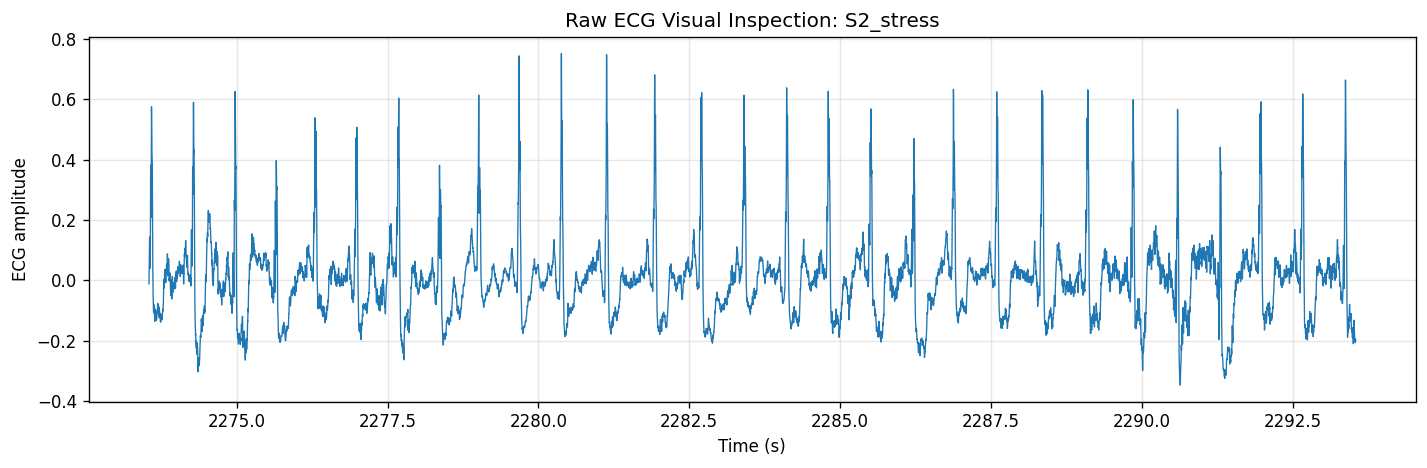

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/raw/S2_stress_raw_ecg.png


In [10]:
plot_raw_ecg_matplotlib(example_file, seconds=20)

# Figure below shows repeating heartbeat-like ECG morphology, with sharp R-peaks visible. 
# This suggests the raw signal is usable.

In [11]:
## Defining Filters

# Below 0.5 Hz: slow baseline drift, respiration drift, electrode drift.
# Above 40 Hz: muscle noise and high-frequency noise.
# ECG R-peaks are mostly preserved within this range

def bandpass_filter(signal, fs=700, lowcut=0.5, highcut=40.0, order=4):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="bandpass")
    filtered = filtfilt(b, a, signal)

    return filtered


def notch_filter(signal, fs=700, notch_freq=50.0, quality_factor=30.0):
    nyquist = fs / 2
    w0 = notch_freq / nyquist

    b, a = iirnotch(w0, quality_factor)
    filtered = filtfilt(b, a, signal)

    return filtered


def preprocess_ecg(signal, fs=700):
    filtered = bandpass_filter(signal, fs=fs, lowcut=0.5, highcut=40.0, order=4)
    filtered = notch_filter(filtered, fs=fs, notch_freq=50.0, quality_factor=30.0)
    return filtered

In [12]:
## Filtered one file : df = pd.read_csv(example_file) 
# This cell loads S2_stress.csv, applies preprocess_ecg, adds a new column

df = pd.read_csv(example_file)

df["ecg_filtered"] = preprocess_ecg(df["ecg_raw"].values, fs=FS)

filtered_file = FILTERED_CSV_DIR / example_file.name
df.to_csv(filtered_file, index=False)

print("Saved filtered file:", filtered_file)
df.head()

Saved filtered file: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/filtered_csv/S2_stress.csv


,subject,sample_index,timestamp_sec,label_id,condition,ecg_raw,ecg_filtered
0,S2,1591482,2273.545714,2,stress,-0.011673,0.153879
1,S2,1591483,2273.547143,2,stress,-0.001556,0.177341
2,S2,1591484,2273.548571,2,stress,0.022385,0.199397
3,S2,1591485,2273.550000,2,stress,0.049622,0.218837
4,S2,1591486,2273.551429,2,stress,0.084457,0.234725


In [13]:
## Raw vs filtered ECG plot: in order to verify if that filtering removed noise without destroying R-peaks.

def plot_raw_vs_filtered_matplotlib(csv_file, seconds=20):
    df = pd.read_csv(csv_file)
    n = int(seconds * FS)
    df_small = df.iloc[:n]

    png_file = FIG_FILTERED_DIR / f"{csv_file.stem}_raw_vs_filtered.png"

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(12, 6),
        sharex=True
    )

    axes[0].plot(
        df_small["timestamp_sec"],
        df_small["ecg_raw"],
        linewidth=0.8
    )
    axes[0].set_title("Raw ECG")
    axes[0].set_ylabel("ECG amplitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        df_small["timestamp_sec"],
        df_small["ecg_filtered"],
        linewidth=0.8
    )
    axes[1].set_title("Filtered ECG")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("ECG amplitude")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"Raw vs Filtered ECG: {csv_file.stem}", y=1.02)
    plt.tight_layout()

    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved PNG:", png_file)

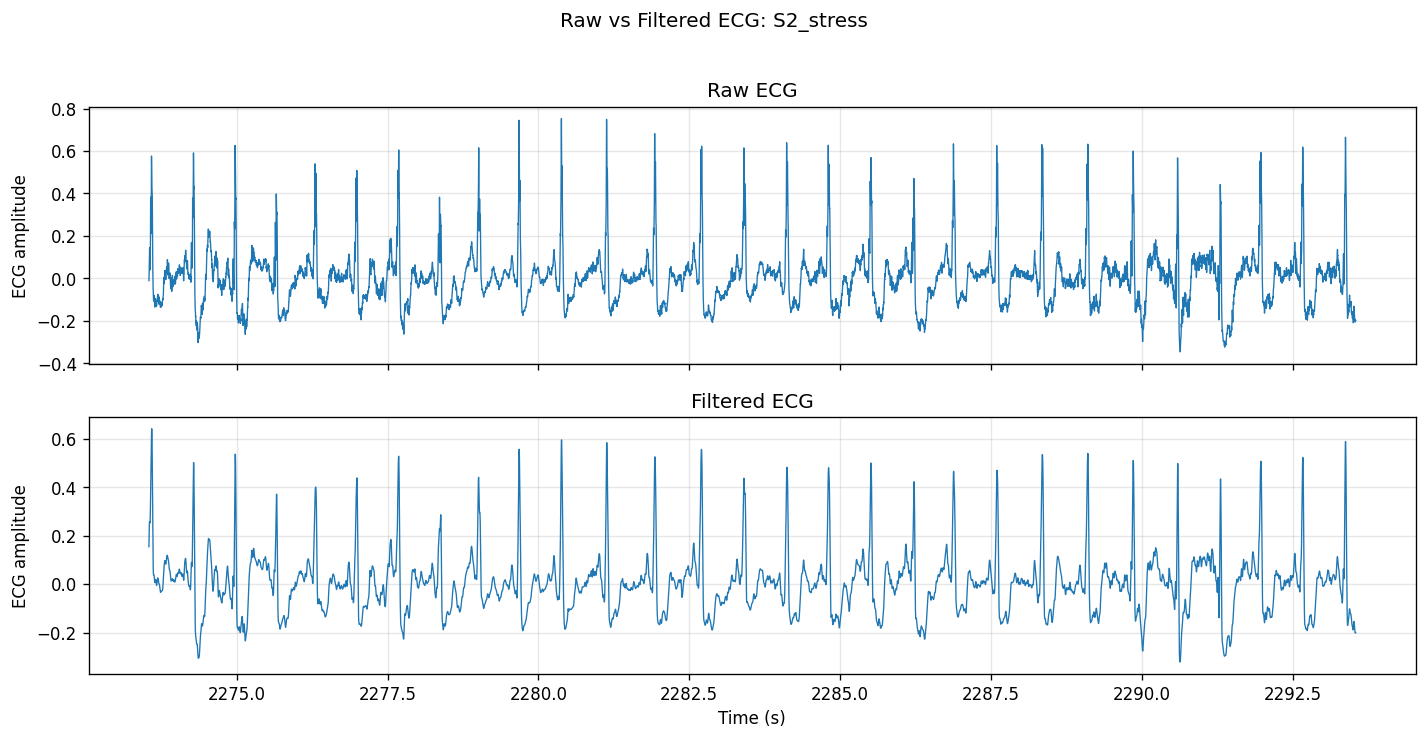

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/filtered/S2_stress_raw_vs_filtered.png


In [14]:
plot_raw_vs_filtered_matplotlib(filtered_file, seconds=20)

In [15]:
# PSD Before and After Plot
# compare frequency content before and after filtering.
# The plot uses:
# x-axis: frequency in Hz
# y-axis: power spectral density on log scale
# raw PSD line
# filtered PSD line
# This shows whether the filter removed unwanted frequencies.

def plot_psd_before_after_matplotlib(csv_file):
    df = pd.read_csv(csv_file)

    raw = df["ecg_raw"].values
    filtered = df["ecg_filtered"].values

    f_raw, p_raw = welch(
        raw,
        fs=FS,
        nperseg=min(4096, len(raw))
    )

    f_filt, p_filt = welch(
        filtered,
        fs=FS,
        nperseg=min(4096, len(filtered))
    )

    png_file = FIG_PSD_DIR / f"{csv_file.stem}_psd_before_after.png"

    plt.figure(figsize=(10, 5))

    plt.semilogy(
        f_raw,
        p_raw,
        linewidth=1.0,
        label="Raw ECG PSD"
    )

    plt.semilogy(
        f_filt,
        p_filt,
        linewidth=1.0,
        label="Filtered ECG PSD"
    )

    plt.xlim(0, 100)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title(f"PSD Before and After Filtering: {csv_file.stem}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved PNG:", png_file)


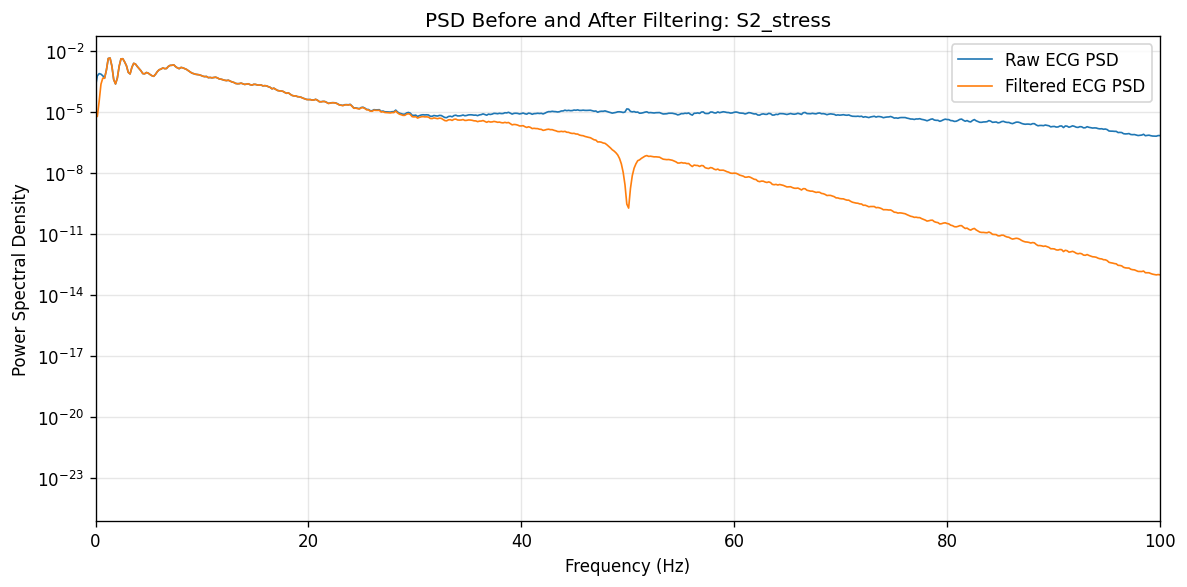

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/psd/S2_stress_psd_before_after.png


In [16]:
plot_psd_before_after_matplotlib(filtered_file)

In [17]:
## Filtering All Files
## every subject-condition file now has an ecg_filtered column.

raw_csv_files = sorted(RAW_CSV_DIR.glob("*.csv"))

for csv_file in tqdm(raw_csv_files):
    df = pd.read_csv(csv_file)
    df["ecg_filtered"] = preprocess_ecg(df["ecg_raw"].values, fs=FS)

    out_file = FILTERED_CSV_DIR / csv_file.name
    df.to_csv(out_file, index=False)

print("Number of filtered files:", len(list(FILTERED_CSV_DIR.glob('*.csv'))))

  0%|          | 0/30 [00:00<?, ?it/s]

Number of filtered files: 30


In [18]:
# Artificat Identification 
## 1. Artificat detection functions 
## This cell defines artifact-detection helpers that is 
# Robust_zscore :Computes a robust z-score using: median, MAD, median absolute deviation
# This is less sensitive to outliers than mean/std. 
# Expand_artifact_mask: If one sample is marked as artifact, this expands the artifact region by 1 second on both sides.
# Mark_artifacts :Marks samples where absolute robust z-score is above threshold, then expands the mask.
# Flaws for ECG, this method can mistake normal R-peaks for artifacts because R-peaks are naturally large. The later cells show exactly that problem.

def robust_zscore(x):
    median = np.median(x)
    mad = np.median(np.abs(x - median))

    if mad == 0:
        std = np.std(x)
    else:
        std = 1.4826 * mad

    if std == 0:
        return np.zeros_like(x)

    return (x - median) / std


def expand_artifact_mask(mask, fs=700, padding_seconds=1.0):
    expanded = mask.copy()
    pad = int(fs * padding_seconds)

    artifact_indices = np.where(mask)[0]

    for idx in artifact_indices:
        start = max(0, idx - pad)
        end = min(len(mask), idx + pad + 1)
        expanded[start:end] = True

    return expanded


def mark_artifacts(ecg_filtered, threshold=5.0, fs=700):
    rz = robust_zscore(ecg_filtered)
    artifact_mask = np.abs(rz) > threshold
    artifact_mask = expand_artifact_mask(artifact_mask, fs=fs, padding_seconds=1.0)
    return artifact_mask

In [19]:
# Marking artificats in one file - TEST

df = pd.read_csv(filtered_file)

artifact_mask = mark_artifacts(df["ecg_filtered"].values, threshold=5.0, fs=FS)

df["artifact_flag"] = artifact_mask.astype(int)

clean_file = CLEAN_CSV_DIR / f"{filtered_file.stem}_marked.csv"
df.to_csv(clean_file, index=False)

print("Saved:", clean_file)
print("Artifact samples:", int(df["artifact_flag"].sum()))
print("Artifact percentage:", round(df["artifact_flag"].mean() * 100, 3), "%")

Saved: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv
Artifact samples: 430500
Artifact percentage: 100.0 %


In [21]:
# Since above cell ECG segment should not have 100% artifact. The thresholding likely identified repeated R-peaks 
# as extreme samples.The 1-second expansion around many peaks caused the entire recording to be covered. Therefore Artifact plotting function
# is defined here: 

def plot_artifacts_matplotlib(csv_file, seconds=20):
    df = pd.read_csv(csv_file)
    n = int(seconds * FS)
    df_small = df.iloc[:n]

    normal = df_small[df_small["artifact_flag"] == 0]
    artifact = df_small[df_small["artifact_flag"] == 1]

    png_file = FIG_ARTIFACT_DIR / f"{csv_file.stem}_artifacts.png"

    plt.figure(figsize=(12, 4))

    plt.plot(
        normal["timestamp_sec"],
        normal["ecg_filtered"],
        linewidth=0.8,
        label="Filtered ECG"
    )

    if len(artifact) > 0:
        plt.scatter(
            artifact["timestamp_sec"],
            artifact["ecg_filtered"],
            s=18,
            label="Marked artifact"
        )

    plt.title(f"Artifact Marking: {csv_file.stem}")
    plt.xlabel("Time (s)")
    plt.ylabel("Filtered ECG amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved PNG:", png_file)
    print("Number of artifact samples shown:", len(artifact))

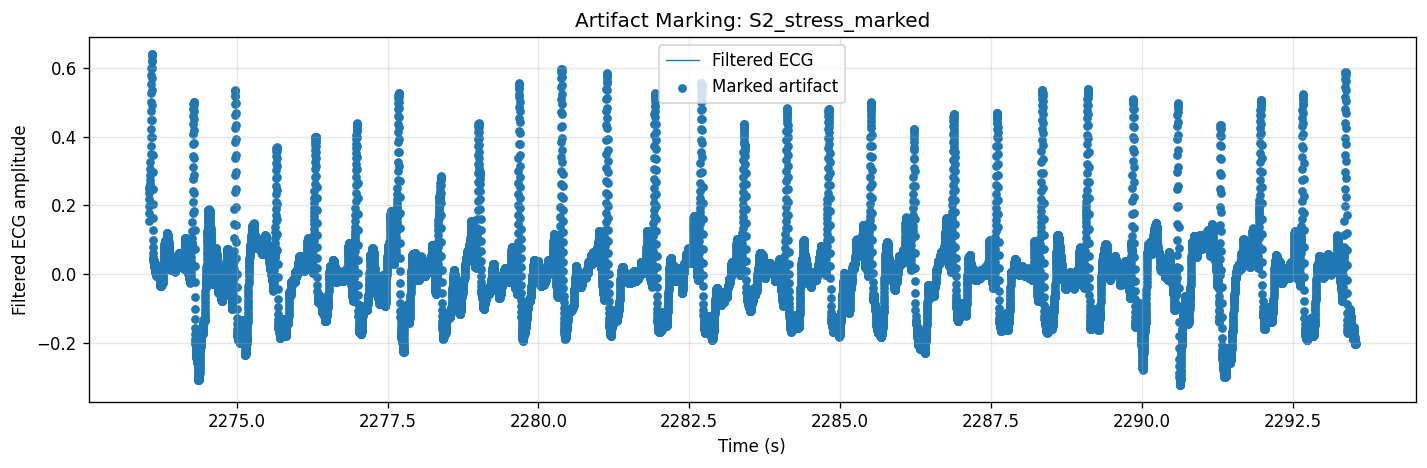

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/artifacts/S2_stress_marked_artifacts.png
Number of artifact samples shown: 14000


In [22]:
plot_artifacts_matplotlib(clean_file, seconds=20)

In [23]:

# Above figure  visually confirms the artifact detector failed. 

filtered_csv_files = sorted(FILTERED_CSV_DIR.glob("*.csv"))

for csv_file in tqdm(filtered_csv_files):
    df = pd.read_csv(csv_file)
    artifact_mask = mark_artifacts(df["ecg_filtered"].values, threshold=5.0, fs=FS)
    df["artifact_flag"] = artifact_mask.astype(int)

    out_file = CLEAN_CSV_DIR / f"{csv_file.stem}_marked.csv"
    df.to_csv(out_file, index=False)

print("Artifact-marked files:", len(list(CLEAN_CSV_DIR.glob('*_marked.csv'))))

  0%|          | 0/30 [00:00<?, ?it/s]

Artifact-marked files: 30


# R-peak detection and HRV extraction

NeuroPype’s cardiac documentation lists RDetection, HeartRate, and HeartRateVariability; the HRV node computes RRI, SDNN, RMSSD, SDSD, NN50, pNN50, NN20, and pNN20 from detected R-peaks.

In [24]:
def interpolate_artifacts(signal, artifact_flag):
    s = pd.Series(signal.copy())
    s[artifact_flag.astype(bool)] = np.nan
    s = s.interpolate(limit_direction="both")
    return s.values

In [25]:

# Defining Safer artificat detection with shorter expansion of 0.1 sec instead of 1 sec 
def mark_artifacts_ecg_safe(ecg_filtered, threshold=8.0, fs=700):
    """
    Safer ECG artifact detection.

    It marks only extreme amplitude spikes instead of marking the whole ECG.
    This prevents the entire ECG from becoming artifact.
    """
    ecg = pd.Series(ecg_filtered)

    # Rolling median and rolling MAD over 5 seconds
    window = int(5 * fs)

    rolling_median = ecg.rolling(
        window=window,
        center=True,
        min_periods=1
    ).median()

    deviation = np.abs(ecg - rolling_median)

    rolling_mad = deviation.rolling(
        window=window,
        center=True,
        min_periods=1
    ).median()

    # Convert MAD to robust standard deviation estimate
    robust_std = 1.4826 * rolling_mad

    # Avoid division by zero
    robust_std = robust_std.replace(0, np.nan)
    robust_std = robust_std.fillna(robust_std.median())

    if robust_std.isna().all() or robust_std.median() == 0:
        print("Warning: robust_std is zero or NaN. No artifacts marked.")
        return np.zeros(len(ecg_filtered), dtype=bool)

    robust_z = deviation / robust_std

    artifact_mask = robust_z > threshold

    # Do NOT expand too aggressively.
    # Only expand by 0.1 second, not 1 second.
    pad = int(0.1 * fs)
    expanded = artifact_mask.to_numpy().copy()

    artifact_indices = np.where(expanded)[0]

    for idx in artifact_indices:
        start = max(0, idx - pad)
        end = min(len(expanded), idx + pad + 1)
        expanded[start:end] = True

    return expanded

In [26]:
# Testing the new above artificat with shorter expansion of 0.1 sec 

df = pd.read_csv(filtered_file)

artifact_mask = mark_artifacts_ecg_safe(
    df["ecg_filtered"].values,
    threshold=8.0,
    fs=FS
)

df["artifact_flag"] = artifact_mask.astype(int)

clean_file = CLEAN_CSV_DIR / f"{filtered_file.stem}_marked.csv"
df.to_csv(clean_file, index=False)

print("Saved:", clean_file)
print("Total samples:", len(df))
print("Artifact samples:", int(df["artifact_flag"].sum()))
print("Artifact percentage:", round(df["artifact_flag"].mean() * 100, 3), "%")
print(df["artifact_flag"].value_counts())

Saved: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv
Total samples: 430500
Artifact samples: 86711
Artifact percentage: 20.142 %
artifact_flag
0    343789
1     86711
Name: count, dtype: int64


In [72]:
# Rechecking arttifact summary 

df = pd.read_csv(clean_file)

print("Total samples:", len(df))
print("Total artifact samples:", df["artifact_flag"].sum())
print("Artifact percentage:", round(df["artifact_flag"].mean() * 100, 3), "%")
print(df["artifact_flag"].value_counts())

Total samples: 430500
Total artifact samples: 86711
Artifact percentage: 20.142 %
artifact_flag
0    343789
1     86711
Name: count, dtype: int64


In [73]:
#cleaning bad artifact file 

bad_clean_file = CLEAN_CSV_DIR / f"{filtered_file.stem}_marked.csv"

print("Bad file path:")
print(bad_clean_file)

if bad_clean_file.exists():
    bad_clean_file.unlink()
    print("Deleted old bad artifact file")
else:
    print("No old file found.")

Bad file path:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv
Deleted old bad artifact file


In [27]:
# This avoids destroying the ECG with a bad detector, but it also means the pipeline no longer performs automatic artifact rejection


def mark_artifacts_none(ecg_filtered):
    """
    Simple safe artifact rule for this project.
    It marks no samples as artifacts automatically.

    Use this when automatic artifact detection incorrectly marks
    the full ECG as artifact.
    """
    return np.zeros(len(ecg_filtered), dtype=bool)

In [28]:
df = pd.read_csv(filtered_file)

artifact_mask = mark_artifacts_none(df["ecg_filtered"].values)

df["artifact_flag"] = artifact_mask.astype(int)

clean_file = CLEAN_CSV_DIR / f"{filtered_file.stem}_marked.csv"
df.to_csv(clean_file, index=False)

print("Saved new clean file:")
print(clean_file)

print("Total samples:", len(df))
print("Artifact samples:", int(df["artifact_flag"].sum()))
print("Artifact percentage:", round(df["artifact_flag"].mean() * 100, 3), "%")
print(df["artifact_flag"].value_counts())

Saved new clean file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv
Total samples: 430500
Artifact samples: 0
Artifact percentage: 0.0 %
artifact_flag
0    430500
Name: count, dtype: int64


In [76]:
df_check = pd.read_csv(clean_file)

print("Checking file:")
print(clean_file)

print("Total samples:", len(df_check))
print("Artifact samples:", int(df_check["artifact_flag"].sum()))
print("Artifact percentage:", round(df_check["artifact_flag"].mean() * 100, 3), "%")
print(df_check["artifact_flag"].value_counts())

Checking file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv
Total samples: 430500
Artifact samples: 0
Artifact percentage: 0.0 %
artifact_flag
0    430500
Name: count, dtype: int64


In [30]:
def interpolate_artifacts_safe(signal, artifact_flag):
    """
    Replace artifact-marked ECG samples with interpolated values.
    artifact_flag: 0 = clean, 1 = artifact
    """

    # Convert to pandas Series so interpolation is easy
    signal_series = pd.Series(signal.copy())

    # Convert artifact flags to True/False mask
    artifact_mask = np.asarray(artifact_flag).astype(bool)

    # Replace artifact samples with NaN
    signal_series[artifact_mask] = np.nan

    # If every sample is marked as artifact, interpolation is impossible
    if signal_series.isna().all():
        raise ValueError(
            "All samples are marked as artifacts. "
            "Cannot interpolate because no clean ECG samples remain."
        )

    # Interpolate missing artifact samples
    signal_series = signal_series.interpolate(
        method="linear",
        limit_direction="both"
    )

    # Safety fill in case NaNs remain at the edges
    signal_series = signal_series.bfill().ffill()

    return signal_series.to_numpy()

In [31]:
filtered_csv_files = sorted(FILTERED_CSV_DIR.glob("*.csv"))

for csv_file in tqdm(filtered_csv_files):
    df = pd.read_csv(csv_file)

    artifact_mask = mark_artifacts_none(df["ecg_filtered"].values)

    df["artifact_flag"] = artifact_mask.astype(int)

    out_file = CLEAN_CSV_DIR / f"{csv_file.stem}_marked.csv"
    df.to_csv(out_file, index=False)

print("Artifact-marked files:", len(list(CLEAN_CSV_DIR.glob('*_marked.csv'))))

  0%|          | 0/30 [00:00<?, ?it/s]

Artifact-marked files: 30


In [32]:
def mark_artifacts_none(ecg_filtered):
    """
    Safe artifact handling rule.

    This function marks no ECG samples as artifacts automatically.

    Reason:
    The previous automatic artifact threshold marked 100% of the ECG
    as artifact. That made R-peak detection impossible.

    For this project, artifacts are handled by:
    1. Visual inspection of raw and filtered ECG.
    2. R-peak detection quality checks.
    3. RR interval validity checks during HRV extraction.
    """
    return np.zeros(len(ecg_filtered), dtype=bool)

In [33]:
# Recreate the clean file for the current example file

df = pd.read_csv(filtered_file)

artifact_mask = mark_artifacts_none(df["ecg_filtered"].values)

df["artifact_flag"] = artifact_mask.astype(int)

clean_file = CLEAN_CSV_DIR / f"{filtered_file.stem}_marked.csv"
df.to_csv(clean_file, index=False)

print("Saved new clean file:")
print(clean_file)

print("\nTotal samples:", len(df))
print("Artifact samples:", int(df["artifact_flag"].sum()))
print("Artifact percentage:", round(df["artifact_flag"].mean() * 100, 3), "%")
print("\nArtifact flag counts:")
print(df["artifact_flag"].value_counts())

Saved new clean file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv

Total samples: 430500
Artifact samples: 0
Artifact percentage: 0.0 %

Artifact flag counts:
artifact_flag
0    430500
Name: count, dtype: int64


In [34]:
filtered_csv_files = sorted(FILTERED_CSV_DIR.glob("*.csv"))

print("Number of filtered files found:", len(filtered_csv_files))

for csv_file in tqdm(filtered_csv_files):
    df = pd.read_csv(csv_file)

    artifact_mask = mark_artifacts_none(df["ecg_filtered"].values)

    df["artifact_flag"] = artifact_mask.astype(int)

    out_file = CLEAN_CSV_DIR / f"{csv_file.stem}_marked.csv"
    df.to_csv(out_file, index=False)

print("Artifact-marked clean files created:", len(list(CLEAN_CSV_DIR.glob('*_marked.csv'))))

Number of filtered files found: 30


  0%|          | 0/30 [00:00<?, ?it/s]

Artifact-marked clean files created: 30


In [35]:
clean_csv_files = sorted(CLEAN_CSV_DIR.glob("*_marked.csv"))

summary_rows = []

for file in clean_csv_files:
    df_check = pd.read_csv(file)

    summary_rows.append({
        "file": file.name,
        "samples": len(df_check),
        "artifact_samples": int(df_check["artifact_flag"].sum()),
        "artifact_percentage": round(df_check["artifact_flag"].mean() * 100, 3)
    })

artifact_summary = pd.DataFrame(summary_rows)

artifact_summary

,file,samples,artifact_samples,artifact_percentage
0,S10_baseline_marked.csv,826000,0,0.0
1,S10_stress_marked.csv,507500,0,0.0
2,S11_baseline_marked.csv,826000,0,0.0
3,S11_stress_marked.csv,476000,0,0.0
4,S13_baseline_marked.csv,826001,0,0.0
5,S13_stress_marked.csv,464800,0,0.0
6,S14_baseline_marked.csv,826000,0,0.0
7,S14_stress_marked.csv,472500,0,0.0
8,S15_baseline_marked.csv,822500,0,0.0
9,S15_stress_marked.csv,480200,0,0.0


In [36]:
# Interpolation Functions

def interpolate_artifacts_safe(signal, artifact_flag):
    """
    Safely interpolate artifact-marked samples.

    If no samples are artifacts, the signal is returned unchanged.
    If some samples are artifacts, they are replaced using linear interpolation.
    If all samples are artifacts, the function raises an error.
    """
    s = pd.Series(signal.copy())
    s[artifact_flag.astype(bool)] = np.nan

    if s.isna().all():
        raise ValueError(
            "All samples in this segment are marked as artifacts. "
            "Choose a cleaner segment or check artifact detection."
        )

    s = s.interpolate(limit_direction="both")

    if s.isna().any():
        s = s.bfill().ffill()

    return s.values

In [37]:
# Detect R-peaks in one clean ECG segment
## This step checks whether the filtered ECG produces clear R-peaks.
## R-peaks are necessary because HRV is calculated from the time intervals between heartbeats.

clean_file = CLEAN_CSV_DIR / "S2_stress_marked.csv"

df = pd.read_csv(clean_file)

print("Loaded file:")
print(clean_file)

print("\nRows:", len(df))
print("Columns:", df.columns.tolist())

print("\nArtifact percentage:", round(df["artifact_flag"].mean() * 100, 3), "%")
print(df["artifact_flag"].value_counts())

Loaded file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv

Rows: 430500
Columns: ['subject', 'sample_index', 'timestamp_sec', 'label_id', 'condition', 'ecg_raw', 'ecg_filtered', 'artifact_flag']

Artifact percentage: 0.0 %
artifact_flag
0    430500
Name: count, dtype: int64


In [39]:
seconds = 20
n = int(seconds * FS)

ecg = df["ecg_filtered"].values[:n]
artifact_flag = df["artifact_flag"].values[:n]
time = df["timestamp_sec"].values[:n]

print("Segment length in samples:", len(ecg))
print("Segment duration:", seconds, "seconds")
print("Artifact samples in segment:", int(artifact_flag.sum()))



##HRV is computed in 60-second windows.
##The window advances every 10 seconds.
## Windows with more than 5% artifacts are rejected.
# i.e Windows need at least 20 beats.
## RR intervals must be between 300 and 2000 ms.


Segment length in samples: 14000
Segment duration: 20 seconds
Artifact samples in segment: 0


In [40]:
ecg_interp = interpolate_artifacts_safe(ecg, artifact_flag)

ecg_cleaned = nk.ecg_clean(
    ecg_interp,
    sampling_rate=FS,
    method="neurokit"
)

signals, info = nk.ecg_peaks(
    ecg_cleaned,
    sampling_rate=FS,
    method="neurokit"
)

rpeaks = info["ECG_R_Peaks"]

print("R-peaks detected:", len(rpeaks))
print("Approximate heart rate:", round(len(rpeaks) / seconds * 60, 1), "BPM")

R-peaks detected: 28
Approximate heart rate: 84.0 BPM


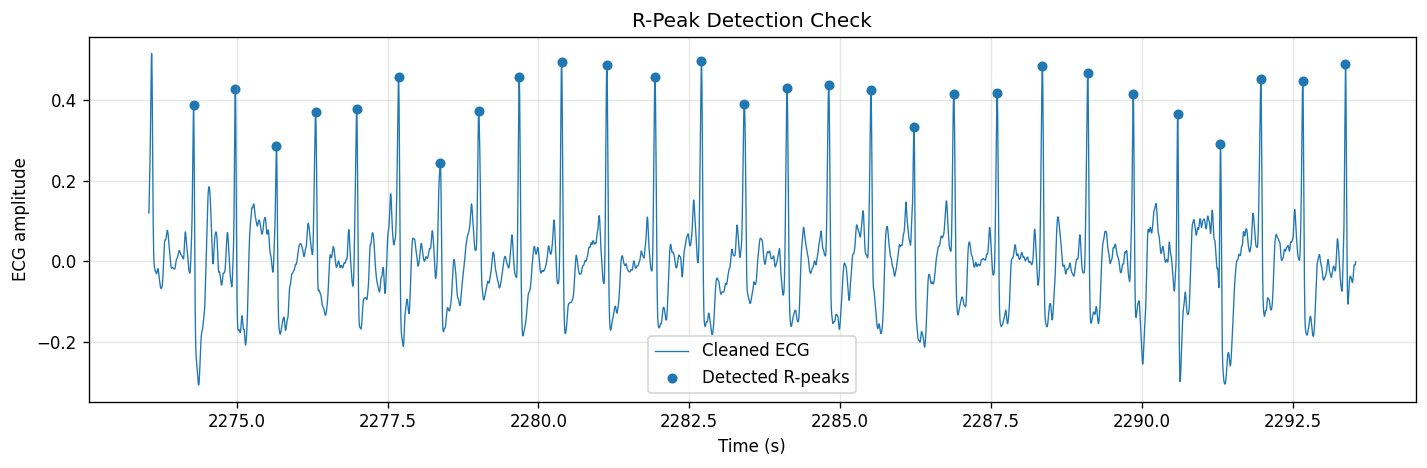

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/rpeaks/S2_stress_rpeaks.png


In [41]:
png_file = FIG_RPEAK_DIR / "S2_stress_rpeaks.png"

plt.figure(figsize=(12, 4))

plt.plot(
    time,
    ecg_cleaned,
    linewidth=0.8,
    label="Cleaned ECG"
)

plt.scatter(
    time[rpeaks],
    ecg_cleaned[rpeaks],
    s=25,
    label="Detected R-peaks"
)

plt.title("R-Peak Detection Check")
plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(png_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PNG:", png_file)

In [43]:
# Defining HRV extraction functions 
# HRV is computed in 60-second windows.
# The window advances every 10 seconds.
# Windows with more than 5% artifacts are rejected.
# Windows need at least 20 beats.
# RR intervals must be between 300 and 2000 ms.
# 300 ms ≈ 200 BPM
# 2000 ms ≈ 30 BPM
# compute_hrv_from_rpeaks
# mean_hr_bpm: average heart rate.
# mean_nn_ms: average normal-to-normal interval.
# sdnn_ms: standard deviation of NN intervals.
# rmssd_ms: root mean square of successive NN differences.
# sdsd_ms: standard deviation of successive differences.
# nn50: number of successive differences above 50 ms.
# pnn50_pct: percentage of successive differences above 50 ms.
# nn20: number above 20 ms.
# pnn20_pct: percentage above 20 ms.
# n_rr: number of valid RR intervals.




WINDOW_SEC = 60
STEP_SEC = 10

MAX_ARTIFACT_FRACTION = 0.05
MIN_BEATS = 20
RR_MIN_MS = 300
RR_MAX_MS = 2000


def compute_hrv_from_rpeaks(rpeaks, fs=700):
    """
    Compute basic time-domain HRV features from R-peak sample indices.
    """
    rr_ms = np.diff(rpeaks) / fs * 1000

    valid = (rr_ms >= RR_MIN_MS) & (rr_ms <= RR_MAX_MS)
    rr_ms = rr_ms[valid]

    if len(rr_ms) < 3:
        return None

    diff_rr = np.diff(rr_ms)

    mean_nn = np.mean(rr_ms)
    sdnn = np.std(rr_ms, ddof=1)
    rmssd = np.sqrt(np.mean(diff_rr ** 2))
    sdsd = np.std(diff_rr, ddof=1)
    nn50 = np.sum(np.abs(diff_rr) > 50)
    pnn50 = np.mean(np.abs(diff_rr) > 50) * 100
    nn20 = np.sum(np.abs(diff_rr) > 20)
    pnn20 = np.mean(np.abs(diff_rr) > 20) * 100
    mean_hr = 60000 / mean_nn

    return {
        "mean_hr_bpm": mean_hr,
        "mean_nn_ms": mean_nn,
        "sdnn_ms": sdnn,
        "rmssd_ms": rmssd,
        "sdsd_ms": sdsd,
        "nn50": nn50,
        "pnn50_pct": pnn50,
        "nn20": nn20,
        "pnn20_pct": pnn20,
        "n_rr": len(rr_ms)
    }


def compute_hrv_windows(csv_file):
    """
    Compute HRV features in sliding windows for one clean ECG CSV file.
    """
    df = pd.read_csv(csv_file)

    subject = df["subject"].iloc[0]
    condition = df["condition"].iloc[0]

    ecg = df["ecg_filtered"].values
    artifact_flag = df["artifact_flag"].values

    window_samples = WINDOW_SEC * FS
    step_samples = STEP_SEC * FS

    rows = []

    for start in range(0, len(df) - window_samples + 1, step_samples):
        end = start + window_samples

        ecg_window = ecg[start:end]
        artifact_window = artifact_flag[start:end]

        artifact_fraction = artifact_window.mean()

        row = {
            "subject": subject,
            "condition": condition,
            "window_start_sec": start / FS,
            "window_end_sec": end / FS,
            "artifact_fraction": artifact_fraction,
            "mean_hr_bpm": np.nan,
            "mean_nn_ms": np.nan,
            "sdnn_ms": np.nan,
            "rmssd_ms": np.nan,
            "sdsd_ms": np.nan,
            "nn50": np.nan,
            "pnn50_pct": np.nan,
            "nn20": np.nan,
            "pnn20_pct": np.nan,
            "n_rr": np.nan,
            "reject_reason": ""
        }

        if artifact_fraction > MAX_ARTIFACT_FRACTION:
            row["reject_reason"] = "too_many_artifacts"
            rows.append(row)
            continue

        ecg_interp = interpolate_artifacts_safe(ecg_window, artifact_window)

        try:
            cleaned = nk.ecg_clean(
                ecg_interp,
                sampling_rate=FS,
                method="neurokit"
            )

            _, info = nk.ecg_peaks(
                cleaned,
                sampling_rate=FS,
                method="neurokit"
            )

            rpeaks = np.asarray(info["ECG_R_Peaks"])

        except Exception:
            row["reject_reason"] = "rpeak_detection_failed"
            rows.append(row)
            continue

        if len(rpeaks) < MIN_BEATS:
            row["reject_reason"] = "too_few_beats"
            rows.append(row)
            continue

        hrv = compute_hrv_from_rpeaks(rpeaks, fs=FS)

        if hrv is None:
            row["reject_reason"] = "not_enough_valid_rr"
            rows.append(row)
            continue

        row.update(hrv)
        rows.append(row)

    return pd.DataFrame(rows)

In [44]:
test_hrv = compute_hrv_windows(clean_file)

print("HRV windows created:", len(test_hrv))
print("Accepted windows:", (test_hrv["reject_reason"] == "").sum())
print("Rejected windows:", (test_hrv["reject_reason"] != "").sum())

test_hrv.head()

HRV windows created: 56
Accepted windows: 56
Rejected windows: 0


,subject,condition,window_start_sec,window_end_sec,artifact_fraction,mean_hr_bpm,mean_nn_ms,sdnn_ms,rmssd_ms,sdsd_ms,nn50,pnn50_pct,nn20,pnn20_pct,n_rr,reject_reason
0,S2,stress,0.0,60.0,0.0,82.104501,730.776014,47.799032,34.662366,34.859648,13,16.250000,39,48.750000,81,
1,S2,stress,10.0,70.0,0.0,81.169223,739.196429,49.130830,36.300078,36.531740,14,17.721519,39,49.367089,80,
2,S2,stress,20.0,80.0,0.0,80.837243,742.232143,52.312004,39.193629,39.443465,15,18.987342,38,48.101266,80,
3,S2,stress,30.0,90.0,0.0,80.127509,748.806510,59.571745,41.402354,41.659727,16,20.512821,36,46.153846,79,
4,S2,stress,40.0,100.0,0.0,79.448998,755.201465,66.633872,46.204468,46.463700,18,23.376623,37,48.051948,78,


In [45]:
## Checking rejection reason: 

test_hrv["reject_reason"].value_counts(dropna=False)

reject_reason
    56
Name: count, dtype: int64

In [46]:
# cComputing HRV for all files 

clean_csv_files = sorted(CLEAN_CSV_DIR.glob("*_marked.csv"))

print("Number of clean files:", len(clean_csv_files))

all_hrv = []

for csv_file in tqdm(clean_csv_files):
    hrv_df = compute_hrv_windows(csv_file)
    all_hrv.append(hrv_df)

hrv_all = pd.concat(all_hrv, ignore_index=True)

hrv_file = FEATURE_DIR / "hrv_windows.csv"
hrv_all.to_csv(hrv_file, index=False)

print("Saved:", hrv_file)
print("Total HRV windows:", len(hrv_all))
hrv_all.head()

Number of clean files: 30


  0%|          | 0/30 [00:00<?, ?it/s]

Saved: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/features/hrv_windows.csv
Total HRV windows: 2599


,subject,condition,window_start_sec,window_end_sec,artifact_fraction,mean_hr_bpm,mean_nn_ms,sdnn_ms,rmssd_ms,sdsd_ms,nn50,pnn50_pct,nn20,pnn20_pct,n_rr,reject_reason
0,S10,baseline,0.0,60.0,0.0,89.277519,672.061688,41.162362,17.641888,17.714591,2,2.298851,15,17.241379,88,
1,S10,baseline,10.0,70.0,0.0,92.089728,651.538462,44.538058,12.337837,12.405715,0,0.000000,8,8.888889,91,
2,S10,baseline,20.0,80.0,0.0,93.146590,644.145963,42.525699,11.245592,11.269475,0,0.000000,7,7.692308,92,
3,S10,baseline,30.0,90.0,0.0,95.075256,631.079027,32.169514,10.339847,10.377519,0,0.000000,5,5.376344,94,
4,S10,baseline,40.0,100.0,0.0,96.488683,621.834586,25.623500,9.645249,9.691657,0,0.000000,4,4.255319,95,


In [50]:
# Keeping accepted HRV windows 

hrv_clean = hrv_all[hrv_all["reject_reason"] == ""].copy()

print("Total windows:", len(hrv_all))
print("Accepted windows:", len(hrv_clean))
print("Rejected windows:", len(hrv_all) - len(hrv_clean))

print("\nRejection reasons:")
print(hrv_all["reject_reason"].value_counts(dropna=False))

hrv_clean.head()

Total windows: 2599
Accepted windows: 2599
Rejected windows: 0

Rejection reasons:
reject_reason
    2599
Name: count, dtype: int64


,subject,condition,window_start_sec,window_end_sec,artifact_fraction,mean_hr_bpm,mean_nn_ms,sdnn_ms,rmssd_ms,sdsd_ms,nn50,pnn50_pct,nn20,pnn20_pct,n_rr,reject_reason
0,S10,baseline,0.0,60.0,0.0,89.277519,672.061688,41.162362,17.641888,17.714591,2,2.298851,15,17.241379,88,
1,S10,baseline,10.0,70.0,0.0,92.089728,651.538462,44.538058,12.337837,12.405715,0,0.000000,8,8.888889,91,
2,S10,baseline,20.0,80.0,0.0,93.146590,644.145963,42.525699,11.245592,11.269475,0,0.000000,7,7.692308,92,
3,S10,baseline,30.0,90.0,0.0,95.075256,631.079027,32.169514,10.339847,10.377519,0,0.000000,5,5.376344,94,
4,S10,baseline,40.0,100.0,0.0,96.488683,621.834586,25.623500,9.645249,9.691657,0,0.000000,4,4.255319,95,


In [51]:
metrics = [
    "mean_hr_bpm",
    "mean_nn_ms",
    "sdnn_ms",
    "rmssd_ms",
    "sdsd_ms",
    "pnn50_pct",
    "pnn20_pct"
]

subject_summary = (
    hrv_clean
    .groupby(["subject", "condition"])[metrics]
    .mean()
    .reset_index()
)

subject_summary_file = RESULT_DIR / "subject_level_hrv.csv"
subject_summary.to_csv(subject_summary_file, index=False)

print("Saved:", subject_summary_file)
subject_summary.head()

Saved: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/results/subject_level_hrv.csv


,subject,condition,mean_hr_bpm,mean_nn_ms,sdnn_ms,rmssd_ms,sdsd_ms,pnn50_pct,pnn20_pct
0,S10,baseline,98.925550,607.420844,35.852887,16.879205,16.955607,1.673944,12.505102
1,S10,stress,106.885767,563.551445,58.476459,32.477914,32.623292,5.080131,21.489707
2,S11,baseline,74.156850,809.911459,58.653077,48.346214,48.671249,29.853948,71.375071
3,S11,stress,124.178560,483.729060,21.853273,7.096201,7.118978,0.157740,1.771870
4,S13,baseline,86.964104,690.364263,51.592078,29.769188,29.931665,6.015212,27.900158


In [52]:
## Statistical Comparison

stats_rows = []

for metric in metrics:
    pivot = subject_summary.pivot(
        index="subject",
        columns="condition",
        values=metric
    )

    if "baseline" not in pivot.columns or "stress" not in pivot.columns:
        continue

    paired = pivot[["baseline", "stress"]].dropna()

    if len(paired) < 2:
        continue

    stat, p = wilcoxon(
        paired["baseline"],
        paired["stress"]
    )

    stats_rows.append({
        "metric": metric,
        "n_subjects": len(paired),
        "baseline_mean": paired["baseline"].mean(),
        "stress_mean": paired["stress"].mean(),
        "wilcoxon_stat": stat,
        "p_value": p
    })

stats_df = pd.DataFrame(stats_rows)

stats_file = RESULT_DIR / "statistics_summary.csv"
stats_df.to_csv(stats_file, index=False)

print("Saved:", stats_file)
stats_df

Saved: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/results/statistics_summary.csv


,metric,n_subjects,baseline_mean,stress_mean,wilcoxon_stat,p_value
0,mean_hr_bpm,15,72.314186,97.000827,0.0,0.000061
1,mean_nn_ms,15,848.367632,642.452541,0.0,0.000061
2,sdnn_ms,15,69.424001,63.301946,51.0,0.638672
3,rmssd_ms,15,52.733772,44.991239,47.0,0.488708
4,sdsd_ms,15,53.120922,45.241022,47.0,0.488708
5,pnn50_pct,15,26.894754,13.948872,26.0,0.055359
6,pnn20_pct,15,58.343326,36.840049,19.0,0.018066


## Paired Wilcoxon Signed-Rank Tests: Baseline vs Stress

This analysis performs paired Wilcoxon signed-rank tests comparing baseline versus stress conditions for each HRV metric.

The goal is to determine whether stress produces statistically significant changes in cardiovascular and heart rate variability measures.
As shown in the result above, fromm mean HR BPM Stress significantly increases HR, and mean NN msStress significantly decreases beat interval. This supports the stress hypothesis mainly for heart rate, mean NN, and pNN20

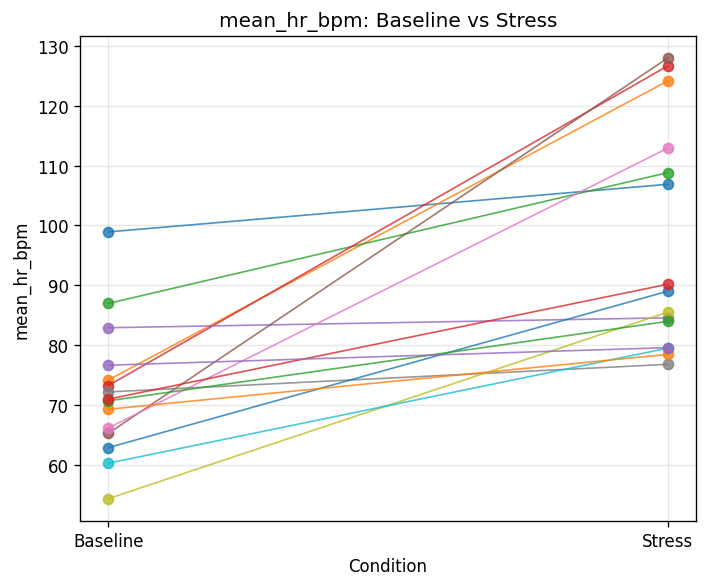

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/mean_hr_bpm_baseline_vs_stress.png


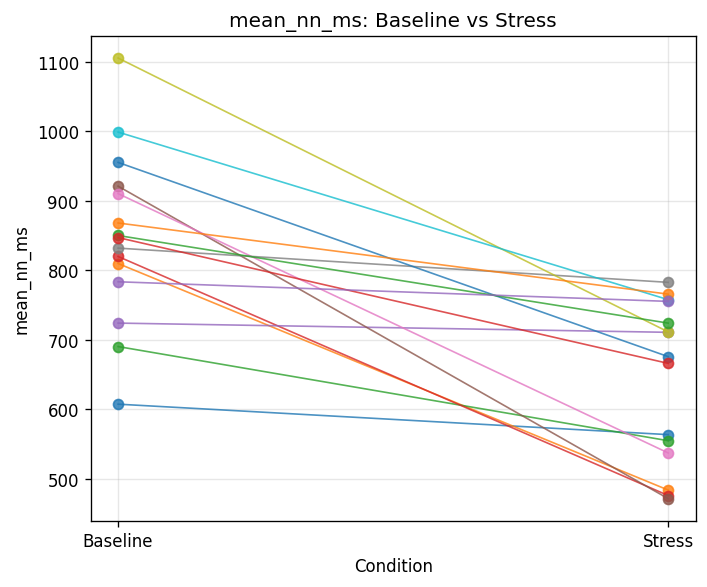

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/mean_nn_ms_baseline_vs_stress.png


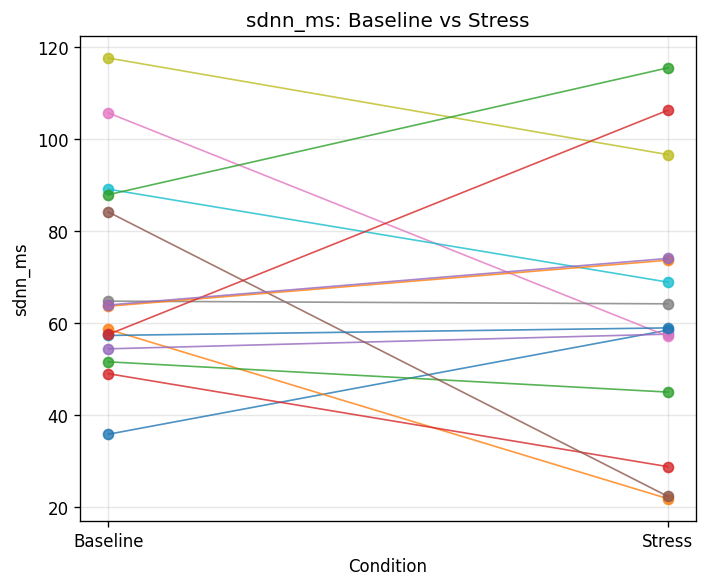

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/sdnn_ms_baseline_vs_stress.png


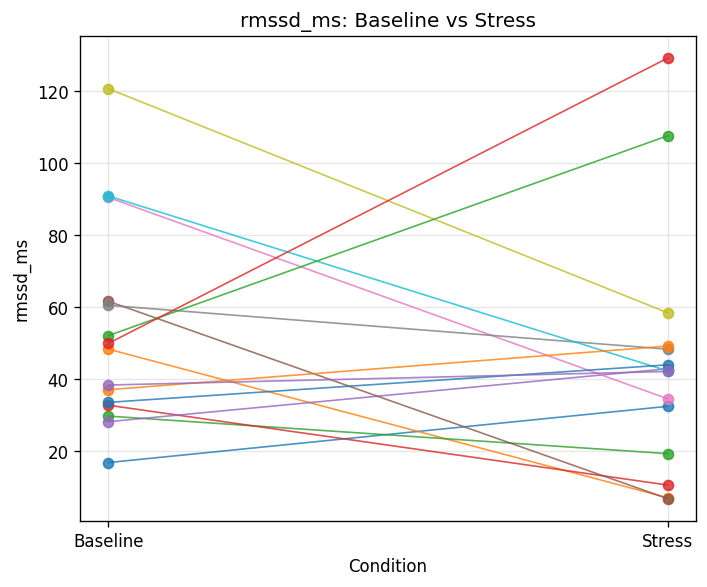

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/rmssd_ms_baseline_vs_stress.png


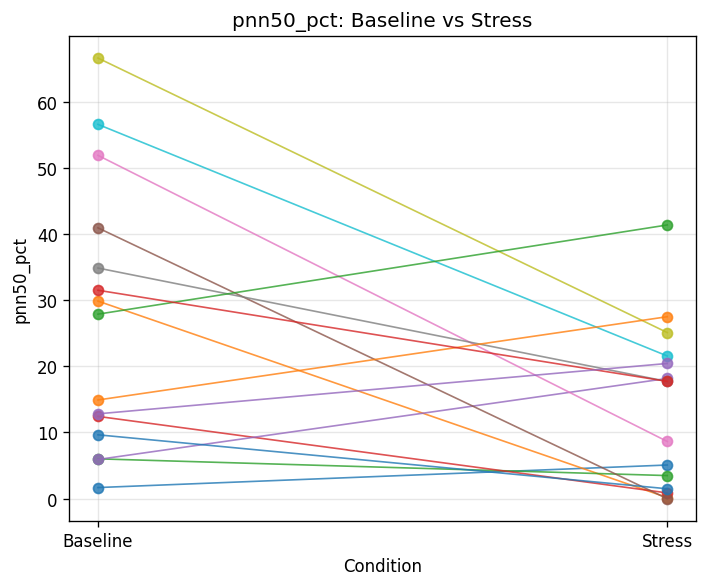

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/pnn50_pct_baseline_vs_stress.png


In [53]:
## HRV results using MATPLOTLIB

def plot_metric_baseline_vs_stress_matplotlib(metric):
    pivot = subject_summary.pivot(
        index="subject",
        columns="condition",
        values=metric
    )

    if "baseline" not in pivot.columns or "stress" not in pivot.columns:
        print("Missing baseline or stress.")
        return

    paired = pivot[["baseline", "stress"]].dropna()

    png_file = FIG_HRV_DIR / f"{metric}_baseline_vs_stress.png"

    plt.figure(figsize=(6, 5))

    for subject, row in paired.iterrows():
        plt.plot(
            ["Baseline", "Stress"],
            [row["baseline"], row["stress"]],
            marker="o",
            linewidth=1,
            alpha=0.8
        )

    plt.title(f"{metric}: Baseline vs Stress")
    plt.xlabel("Condition")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved PNG:", png_file)


for metric in ["mean_hr_bpm", "mean_nn_ms", "sdnn_ms", "rmssd_ms", "pnn50_pct"]:
    plot_metric_baseline_vs_stress_matplotlib(metric)

In [99]:
from scipy.stats import wilcoxon

metrics = [
    "mean_hr_bpm",
    "mean_nn_ms",
    "sdnn_ms",
    "rmssd_ms",
    "sdsd_ms",
    "pnn50_pct",
    "pnn20_pct"
]

stats_rows = []

for metric in metrics:
    pivot = subject_summary.pivot(
        index="subject",
        columns="condition",
        values=metric
    )

    if "baseline" not in pivot.columns or "stress" not in pivot.columns:
        print(f"Skipping {metric}: missing baseline or stress.")
        continue

    paired = pivot[["baseline", "stress"]].dropna()

    if len(paired) < 2:
        print(f"Skipping {metric}: not enough paired subjects.")
        continue

    stat, p = wilcoxon(
        paired["baseline"],
        paired["stress"]
    )

    stats_rows.append({
        "metric": metric,
        "n_subjects": len(paired),
        "baseline_mean": paired["baseline"].mean(),
        "baseline_std": paired["baseline"].std(),
        "stress_mean": paired["stress"].mean(),
        "stress_std": paired["stress"].std(),
        "wilcoxon_stat": stat,
        "p_value": p
    })

stats_df = pd.DataFrame(stats_rows)

stats_file = RESULT_DIR / "statistics_summary.csv"
stats_df.to_csv(stats_file, index=False)

print("Saved statistics summary:")
print(stats_file)

stats_df

Saved statistics summary:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/results/statistics_summary.csv


,metric,n_subjects,baseline_mean,baseline_std,stress_mean,stress_std,wilcoxon_stat,p_value
0,mean_hr_bpm,15,72.314186,11.078833,97.000827,18.903646,0.0,0.000061
1,mean_nn_ms,15,848.367632,123.985628,642.452541,115.251961,0.0,0.000061
2,sdnn_ms,15,69.424001,22.618848,63.301946,27.991105,51.0,0.638672
3,rmssd_ms,15,52.733772,28.375481,44.991239,34.021124,47.0,0.488708
4,sdsd_ms,15,53.120922,28.651740,45.241022,34.227865,47.0,0.488708
5,pnn50_pct,15,26.894754,20.233086,13.948872,12.341356,26.0,0.055359
6,pnn20_pct,15,58.343326,21.420175,36.840049,23.774181,19.0,0.018066


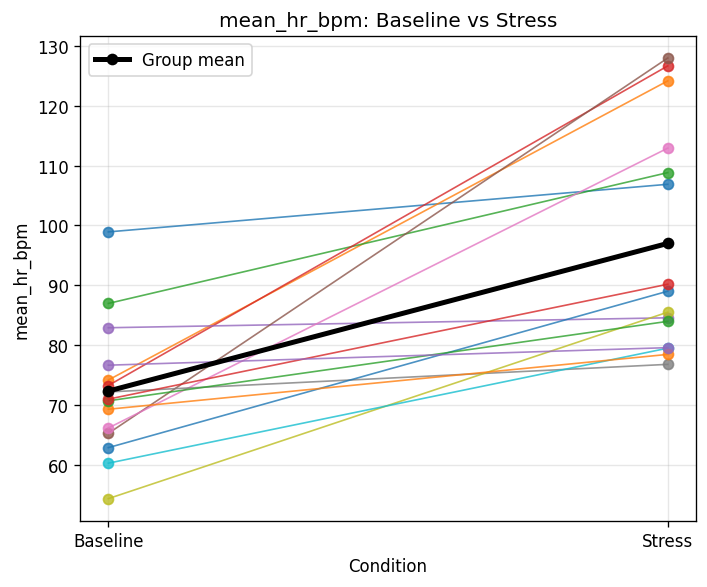

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/mean_hr_bpm_baseline_vs_stress.png


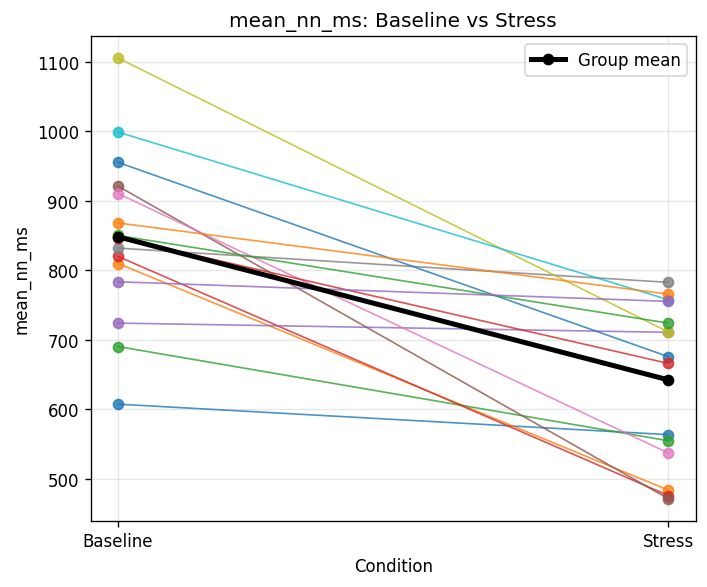

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/mean_nn_ms_baseline_vs_stress.png


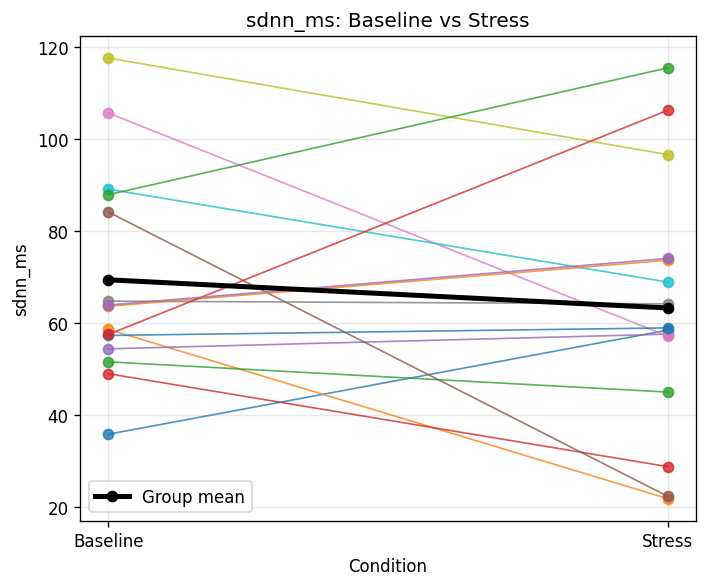

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/sdnn_ms_baseline_vs_stress.png


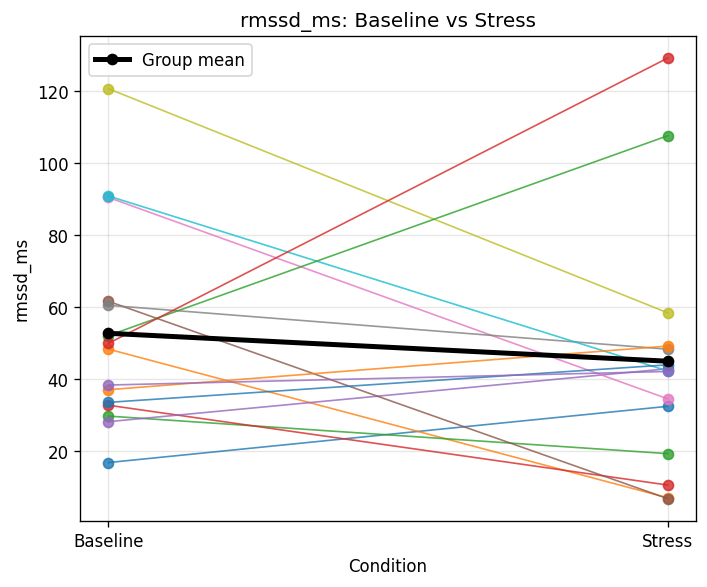

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/rmssd_ms_baseline_vs_stress.png


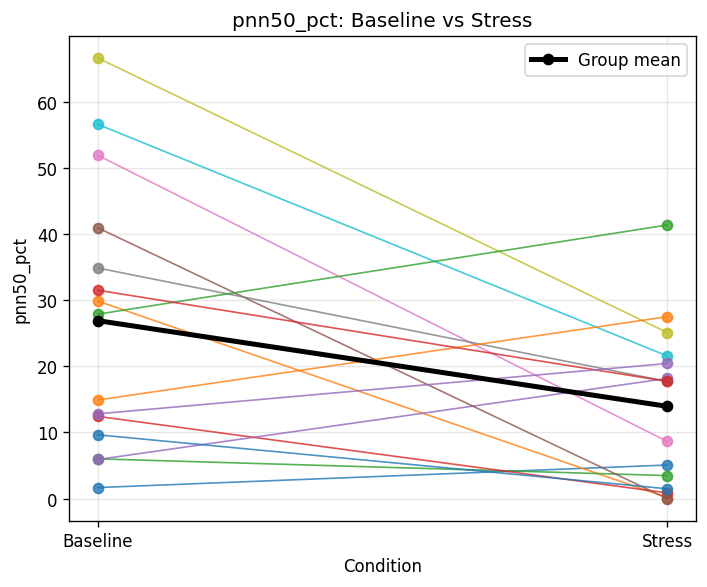

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/hrv/pnn50_pct_baseline_vs_stress.png


In [100]:
def plot_metric_baseline_vs_stress_matplotlib(metric):
    pivot = subject_summary.pivot(
        index="subject",
        columns="condition",
        values=metric
    )

    if "baseline" not in pivot.columns or "stress" not in pivot.columns:
        print(f"Skipping {metric}: missing baseline or stress.")
        return

    paired = pivot[["baseline", "stress"]].dropna()

    if len(paired) == 0:
        print(f"Skipping {metric}: no paired data.")
        return

    png_file = FIG_HRV_DIR / f"{metric}_baseline_vs_stress.png"

    plt.figure(figsize=(6, 5))

    for subject, row in paired.iterrows():
        plt.plot(
            ["Baseline", "Stress"],
            [row["baseline"], row["stress"]],
            marker="o",
            linewidth=1,
            alpha=0.8
        )

    baseline_mean = paired["baseline"].mean()
    stress_mean = paired["stress"].mean()

    plt.plot(
        ["Baseline", "Stress"],
        [baseline_mean, stress_mean],
        marker="o",
        linewidth=3,
        color="black",
        label="Group mean"
    )

    plt.title(f"{metric}: Baseline vs Stress")
    plt.xlabel("Condition")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved PNG:", png_file)


for metric in [
    "mean_hr_bpm",
    "mean_nn_ms",
    "sdnn_ms",
    "rmssd_ms",
    "pnn50_pct"
]:
    plot_metric_baseline_vs_stress_matplotlib(metric)

In [54]:
## Building Machine learning Feature MATRIX 


feature_columns = [
    "mean_hr_bpm",
    "mean_nn_ms",
    "sdnn_ms",
    "rmssd_ms",
    "sdsd_ms",
    "pnn50_pct",
    "pnn20_pct"
]

ml_df = hrv_clean.dropna(subset=feature_columns).copy()

ml_df["label"] = ml_df["condition"].map({
    "baseline": 0,
    "stress": 1
})

X = ml_df[feature_columns].values.astype(np.float32)
y = ml_df["label"].values.astype(np.float32)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

print("\nClass counts:")
print(ml_df["condition"].value_counts())

ml_df.head()

Feature matrix shape: (2599, 7)
Label vector shape: (2599,)

Class counts:
condition
baseline    1682
stress       917
Name: count, dtype: int64


,subject,condition,window_start_sec,window_end_sec,artifact_fraction,mean_hr_bpm,mean_nn_ms,sdnn_ms,rmssd_ms,sdsd_ms,nn50,pnn50_pct,nn20,pnn20_pct,n_rr,reject_reason,label
0,S10,baseline,0.0,60.0,0.0,89.277519,672.061688,41.162362,17.641888,17.714591,2,2.298851,15,17.241379,88,,0
1,S10,baseline,10.0,70.0,0.0,92.089728,651.538462,44.538058,12.337837,12.405715,0,0.000000,8,8.888889,91,,0
2,S10,baseline,20.0,80.0,0.0,93.146590,644.145963,42.525699,11.245592,11.269475,0,0.000000,7,7.692308,92,,0
3,S10,baseline,30.0,90.0,0.0,95.075256,631.079027,32.169514,10.339847,10.377519,0,0.000000,5,5.376344,94,,0
4,S10,baseline,40.0,100.0,0.0,96.488683,621.834586,25.623500,9.645249,9.691657,0,0.000000,4,4.255319,95,,0


In [56]:
## 

feature_columns = [
    "mean_hr_bpm",
    "mean_nn_ms",
    "sdnn_ms",
    "rmssd_ms",
    "sdsd_ms",
    "pnn50_pct",
    "pnn20_pct"
]

ml_df = hrv_clean.dropna(subset=feature_columns).copy()

ml_df["label"] = ml_df["condition"].map({
    "baseline": 0,
    "stress": 1
})

X = ml_df[feature_columns].values.astype(np.float32)
y = ml_df["label"].values.astype(np.float32)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

print("\nClass counts:")
print(ml_df["condition"].value_counts())

ml_df.head()

Feature matrix shape: (2599, 7)
Label vector shape: (2599,)

Class counts:
condition
baseline    1682
stress       917
Name: count, dtype: int64


,subject,condition,window_start_sec,window_end_sec,artifact_fraction,mean_hr_bpm,mean_nn_ms,sdnn_ms,rmssd_ms,sdsd_ms,nn50,pnn50_pct,nn20,pnn20_pct,n_rr,reject_reason,label
0,S10,baseline,0.0,60.0,0.0,89.277519,672.061688,41.162362,17.641888,17.714591,2,2.298851,15,17.241379,88,,0
1,S10,baseline,10.0,70.0,0.0,92.089728,651.538462,44.538058,12.337837,12.405715,0,0.000000,8,8.888889,91,,0
2,S10,baseline,20.0,80.0,0.0,93.146590,644.145963,42.525699,11.245592,11.269475,0,0.000000,7,7.692308,92,,0
3,S10,baseline,30.0,90.0,0.0,95.075256,631.079027,32.169514,10.339847,10.377519,0,0.000000,5,5.376344,94,,0
4,S10,baseline,40.0,100.0,0.0,96.488683,621.834586,25.623500,9.645249,9.691657,0,0.000000,4,4.255319,95,,0


In [57]:
## 

feature_columns = [
    "mean_hr_bpm",
    "mean_nn_ms",
    "sdnn_ms",
    "rmssd_ms",
    "sdsd_ms",
    "pnn50_pct",
    "pnn20_pct"
]

ml_df = hrv_clean.dropna(subset=feature_columns).copy()

ml_df["label"] = ml_df["condition"].map({
    "baseline": 0,
    "stress": 1
})

X = ml_df[feature_columns].values.astype(np.float32)
y = ml_df["label"].values.astype(np.float32)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Class counts:")
print(ml_df["condition"].value_counts())

Feature matrix shape: (2599, 7)
Label vector shape: (2599,)
Class counts:
condition
baseline    1682
stress       917
Name: count, dtype: int64


In [63]:

# Standarized feature using JAX 
X_jax = jnp.asarray(X)

@jit
def jax_standardize(X):
    mean = jnp.mean(X, axis=0)
    std = jnp.std(X, axis=0)
    std = jnp.where(std == 0, 1.0, std)
    X_scaled = (X - mean) / std
    return X_scaled, mean, std

X_scaled_jax, X_mean_jax, X_std_jax = jax_standardize(X_jax)
X_scaled = np.array(X_scaled_jax)

print("Mean after scaling:")
print(np.round(X_scaled.mean(axis=0), 4))

print("\nStandard deviation after scaling:")
print(np.round(X_scaled.std(axis=0), 4))

Mean after scaling:
[-0. -0.  0.  0. -0. -0.  0.]

Standard deviation after scaling:
[1. 1. 1. 1. 1. 1. 1.]


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train_j = jnp.asarray(X_train)
X_test_j = jnp.asarray(X_test)
y_train_j = jnp.asarray(y_train)
y_test_j = jnp.asarray(y_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1949
Testing samples: 650


In [67]:
def sigmoid(z):
    return 1 / (1 + jnp.exp(-z))


def predict_prob(params, X):
    w, b = params
    return sigmoid(jnp.dot(X, w) + b)


def binary_cross_entropy(params, X, y):
    probs = predict_prob(params, X)
    eps = 1e-7

    loss = -jnp.mean(
        y * jnp.log(probs + eps) +
        (1 - y) * jnp.log(1 - probs + eps)
    )

    return loss


loss_grad = jit(grad(binary_cross_entropy))


@jit
def update(params, X, y, lr=0.05):
    grads = loss_grad(params, X, y)
    w, b = params
    dw, db = grads
    return (w - lr * dw, b - lr * db)

In [69]:
n_features = X_train.shape[1]

params = (
    jnp.zeros(n_features),
    jnp.array(0.0)
)

loss_history = []

for epoch in range(1000):
    params = update(params, X_train_j, y_train_j, lr=0.05)

    if epoch % 50 == 0:
        loss = binary_cross_entropy(params, X_train_j, y_train_j)
        loss_history.append(float(loss))

final_loss = binary_cross_entropy(params, X_train_j, y_train_j)

print("Final training loss:", float(final_loss))

test_probs = np.array(predict_prob(params, X_test_j))
test_pred = (test_probs >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, test_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=["baseline", "stress"]
))

Final training loss: 0.3236481845378876
Accuracy: 0.8661538461538462

Confusion matrix:
[[399  22]
 [ 65 164]]

Classification report:
              precision    recall  f1-score   support

    baseline       0.86      0.95      0.90       421
      stress       0.88      0.72      0.79       229

    accuracy                           0.87       650
   macro avg       0.87      0.83      0.85       650
weighted avg       0.87      0.87      0.86       650



In [70]:
test_probs = np.array(predict_prob(params, X_test_j))
test_pred = (test_probs >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, test_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=["baseline", "stress"]
))

Accuracy: 0.8661538461538462

Confusion matrix:
[[399  22]
 [ 65 164]]

Classification report:
              precision    recall  f1-score   support

    baseline       0.86      0.95      0.90       421
      stress       0.88      0.72      0.79       229

    accuracy                           0.87       650
   macro avg       0.87      0.83      0.85       650
weighted avg       0.87      0.87      0.86       650



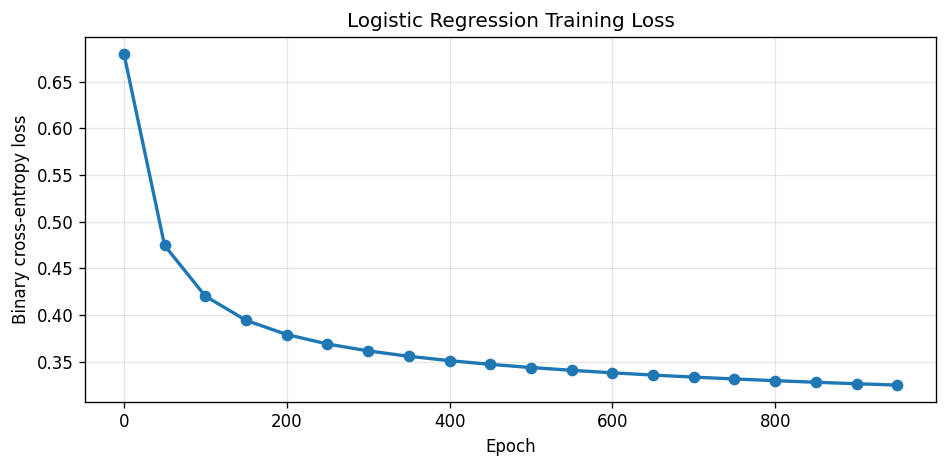

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/latent_space/jax_training_loss.png


In [77]:
png_file = FIG_LATENT_DIR / "jax_training_loss.png"

epochs = list(range(0, 1000, 50))

plt.figure(figsize=(8, 4))
plt.plot(
    epochs,
    loss_history,
    marker="o",
    linewidth=2
)

plt.title("Logistic Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(png_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PNG:", png_file)


In [79]:
def plot_2d_embedding_matplotlib(embedding, labels, title, output_name):
    plot_df = pd.DataFrame({
        "Dim1": embedding[:, 0],
        "Dim2": embedding[:, 1],
        "condition": labels
    })

    png_file = FIG_LATENT_DIR / f"{output_name}.png"

    plt.figure(figsize=(7, 6))

    for condition in sorted(plot_df["condition"].unique()):
        sub = plot_df[plot_df["condition"] == condition]

        plt.scatter(
            sub["Dim1"],
            sub["Dim2"],
            s=25,
            alpha=0.75,
            label=condition
        )

    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved PNG:", png_file)

PCA explained variance ratio:
[0.75662005 0.15495431]


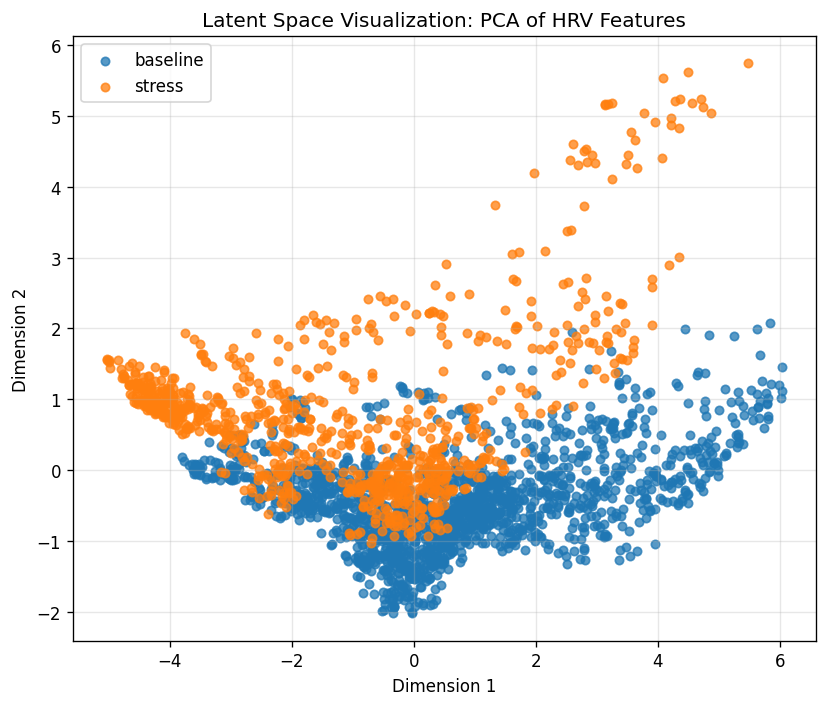

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/latent_space/pca_hrv_latent_space.png


In [74]:
condition_labels = ml_df["condition"].values

pca = PCA(n_components=2, random_state=42)
pca_embedding = pca.fit_transform(X_scaled)

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)

plot_2d_embedding_matplotlib(
    pca_embedding,
    condition_labels,
    "Latent Space Visualization: PCA of HRV Features",
    "pca_hrv_latent_space"
)

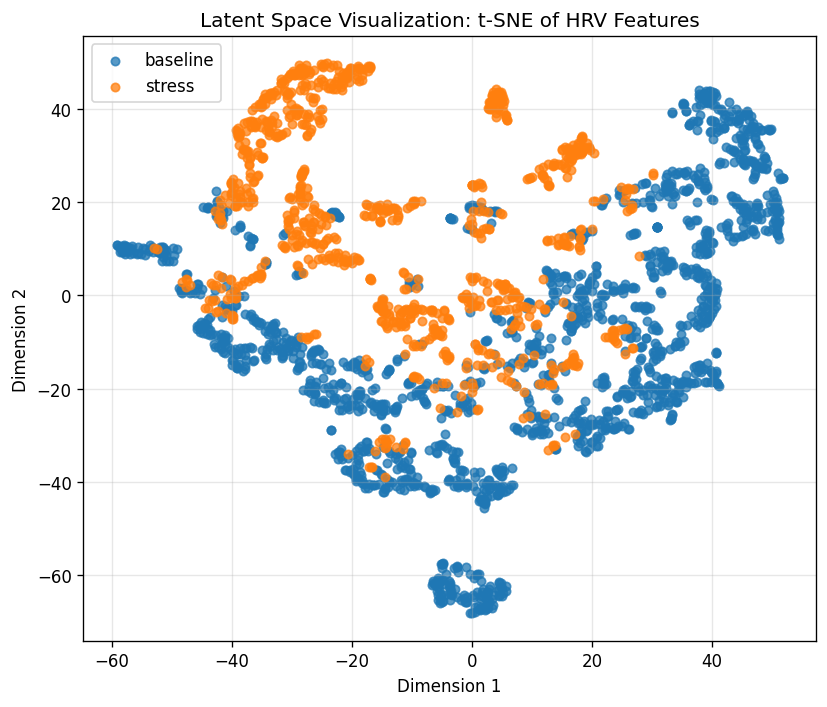

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/latent_space/tsne_hrv_latent_space.png


In [75]:
n_samples = X_scaled.shape[0]
perplexity_value = min(30, max(5, n_samples // 4))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity_value,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding = tsne.fit_transform(X_scaled)

plot_2d_embedding_matplotlib(
    tsne_embedding,
    condition_labels,
    f"Latent Space Visualization: t-SNE of HRV Features",
    "tsne_hrv_latent_space"
)

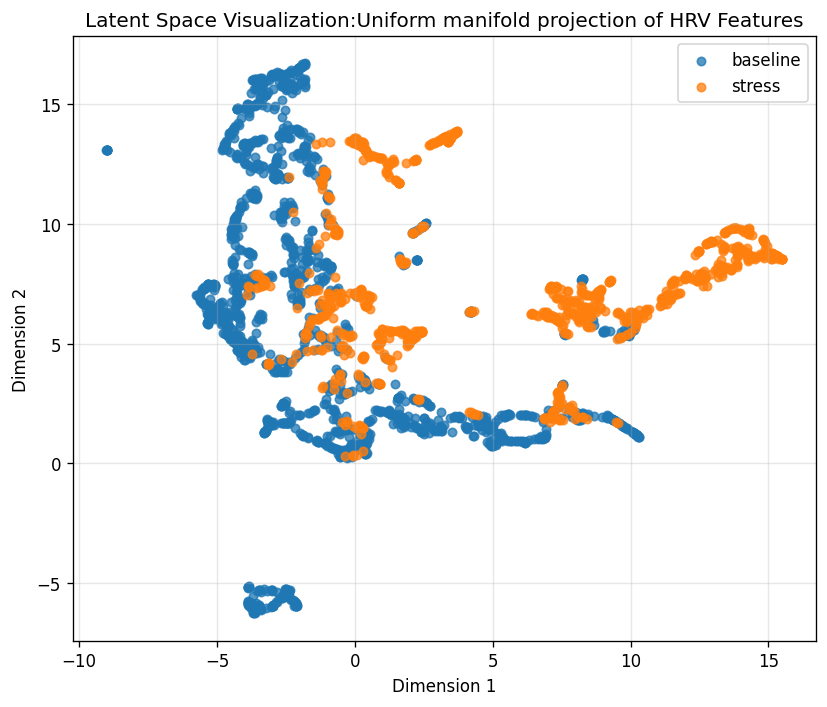

Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/latent_space/umap_hrv_latent_space.png


In [80]:
umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

umap_embedding = umap_model.fit_transform(X_scaled)

plot_2d_embedding_matplotlib(
    umap_embedding,
    condition_labels,
    "Latent Space Visualization:Uniform manifold projection of HRV Features",
    "umap_hrv_latent_space"
)

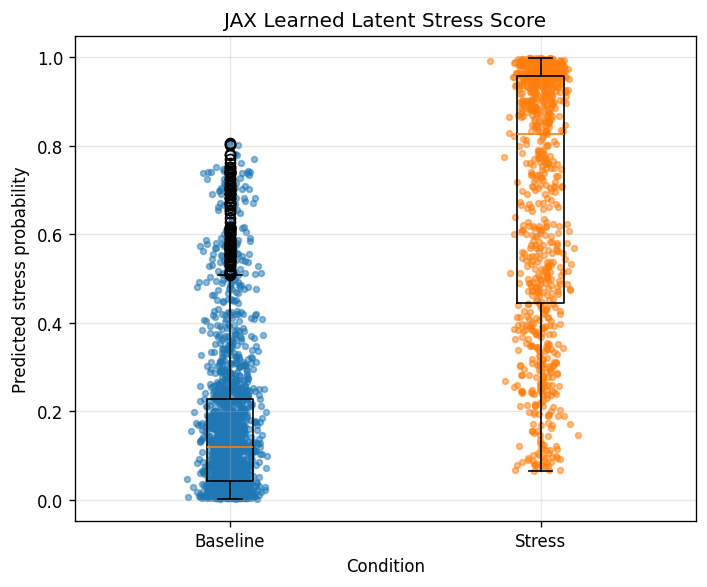

Saved latent score CSV: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/results/jax_latent_scores.csv
Saved PNG: /home/xzkhu/Documents/ecg-hrv-wesad-neuropype/figures/latent_space/jax_latent_stress_score.png


In [81]:
all_probs = np.array(predict_prob(params, jnp.asarray(X_scaled)))

jax_latent_df = ml_df.copy()
jax_latent_df["jax_stress_probability"] = all_probs

latent_file = RESULT_DIR / "jax_latent_scores.csv"
jax_latent_df.to_csv(latent_file, index=False)

png_file = FIG_LATENT_DIR / "jax_latent_stress_score.png"

plt.figure(figsize=(6, 5))

conditions = ["baseline", "stress"]
data_to_plot = [
    jax_latent_df[jax_latent_df["condition"] == condition]["jax_stress_probability"]
    for condition in conditions
]

plt.boxplot(
    data_to_plot,
    labels=["Baseline", "Stress"],
    showfliers=True
)

for i, condition in enumerate(conditions, start=1):
    values = jax_latent_df[
        jax_latent_df["condition"] == condition
    ]["jax_stress_probability"]

    x_jitter = np.random.normal(i, 0.04, size=len(values))

    plt.scatter(
        x_jitter,
        values,
        alpha=0.5,
        s=12
    )

plt.title("JAX Learned Latent Stress Score")
plt.xlabel("Condition")
plt.ylabel("Predicted stress probability")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(png_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved latent score CSV:", latent_file)
print("Saved PNG:", png_file)

# Elaboration of above models visualization(figures) in details:


## HRV Paired Plots

The HRV paired plots compare each subject’s baseline and stress values for the selected HRV metrics. Each thin line represents one subject and shows the direction of change from baseline to stress.

This paired visualization is useful because it shows within-subject physiological changes rather than only comparing group averages. The thick black line represents the group mean trend and summarizes the overall direction of change across subjects.

---

## Mean Heart Rate Plot

The mean heart rate plot shows a clear increase from baseline to stress for most subjects.

This indicates that heart rate rises during the stress condition. Physiologically, this pattern is consistent with sympathetic nervous system activation during stress. When stress increases, cardiovascular activity also increases, leading to faster heartbeats.

**Conclusion:** Stress increases heart rate.

---

## Mean NN Interval Plot

The mean NN interval plot shows that most subjects have lower NN intervals during stress compared with baseline.

NN interval represents the time between consecutive normal heartbeats. A decrease in NN interval means that the time between heartbeats becomes shorter. This is consistent with the observed increase in heart rate.

**Conclusion:** Stress shortens the time between heartbeats.

---

## SDNN Plot

The SDNN plot shows mixed subject-level changes between baseline and stress.

Some subjects show a decrease, while others show little change or an increase. SDNN reflects overall variability in normal-to-normal heartbeat intervals. Because the direction of change is not consistent across subjects, this plot does not show a clear stress-related pattern.

**Conclusion:** SDNN does not show a consistent stress effect in this notebook.

---

## RMSSD Plot

The RMSSD plot shows variable responses across subjects.

Some subjects show lower RMSSD during stress, while others remain similar or increase. RMSSD reflects short-term heart rate variability and is commonly associated with parasympathetic regulation.

Although stress may reduce parasympathetic activity, the pattern here is not consistent enough across subjects to support a reliable decrease.

**Conclusion:** RMSSD does not show a statistically reliable stress-related decrease in this analysis.

---

## pNN50 Plot

The pNN50 plot shows that many subjects have lower pNN50 values during stress compared with baseline, although not all subjects follow this pattern.

pNN50 measures the percentage of adjacent NN intervals differing by more than 50 ms. Lower pNN50 values suggest reduced beat-to-beat variability, which may reflect reduced parasympathetic activity during stress.

However, because the decrease is not consistent across all subjects and the Wilcoxon p-value is borderline, this should be interpreted as a possible reduction rather than a strong confirmed effect.

**Conclusion:** pNN50 shows a likely stress-related reduction, but the evidence is borderline.

---

## Binary Cross-Entropy Loss Plot

The binary cross-entropy loss plot shows model loss across training epochs.

The x-axis represents epoch, and the y-axis represents loss. The curve decreases smoothly during training, indicating that the logistic-regression model is learning from the HRV features.

A smooth decrease in loss suggests that optimization is numerically stable. There is no clear evidence of unstable training, divergence, or strong oscillation.

**Conclusion:** The logistic-regression model is learning, and training is numerically stable.

---

## PCA Latent-Space Plot

The PCA latent-space plot projects the HRV features into two principal components.

The x-axis represents the first principal component, and the y-axis represents the second principal component. The colors represent baseline and stress conditions.

The first principal component explains 75.7% of the variance, while the second principal component explains 15.5%. Together, these two components capture most of the variation in the HRV feature set.

The plot shows partial separation between baseline and stress, suggesting that HRV features contain condition-related structure. However, overlap remains between the two groups, meaning that baseline and stress are not perfectly separable using these features alone.

**Conclusion:** HRV features contain stress-related structure, but baseline and stress still overlap.

---

## t-SNE Latent-Space Plot

The t-SNE latent-space plot shows a nonlinear embedding of the HRV windows.

The axes are arbitrary t-SNE dimensions and do not have direct physiological meaning. Points that are close together have similar HRV feature profiles. Colors indicate baseline and stress conditions.

Some local regions appear enriched for one condition, suggesting that certain HRV patterns are more common during either baseline or stress.

However, t-SNE should not be overinterpreted because it can create apparent clusters depending on parameter settings and local neighborhood structure.

**Conclusion:** Some local clusters are condition-enriched, but the plot should be interpreted cautiously.

---

## UMAP Latent-Space Plot

The UMAP latent-space plot shows another nonlinear embedding of the HRV feature space.

The x-axis represents UMAP dimension 1, and the y-axis represents UMAP dimension 2. These axes are embedding coordinates and should not be interpreted as direct physiological measurements.

The plot shows some separation between baseline and stress points, suggesting that HRV features contain information related to stress condition. However, overlap remains between the two groups.

This overlap indicates that HRV features do not perfectly distinguish stress from baseline, likely because of individual differences and physiological variability.

**Conclusion:** Some condition separation exists, but HRV features do not perfectly separate stress from baseline.

---

## JAX Latent Stress Score Plot

The JAX latent stress score plot shows predicted stress probability for baseline and stress windows.

The x-axis represents condition, and the y-axis represents predicted stress probability. The boxplot summarizes the distribution of predicted probabilities, while the jittered points show individual windows.

Stress windows generally receive higher predicted stress probabilities than baseline windows. This suggests that the model learned a stress-related signal from the HRV features.

However, there is overlap between the baseline and stress distributions. Some baseline windows receive relatively high stress probabilities, and some stress windows receive lower probabilities.

**Conclusion:** Stress windows generally receive higher stress probabilities, but the classifier is not perfect.

---

## Overall Summary

The plots provide visual support for the stress hypothesis. The strongest and most consistent effects are observed in mean heart rate and mean NN interval. Heart rate increases during stress, while NN interval decreases, showing faster cardiac activity under stress.

Some HRV variability measures, such as pNN50, suggest a possible reduction during stress, but the evidence is weaker and less consistent. SDNN and RMSSD show mixed subject-level responses and do not demonstrate a clear stress effect.

The PCA, t-SNE, UMAP, and JAX stress score plots show that HRV features contain condition-related information. However, overlap between baseline and stress remains, indicating that HRV-based stress detection is informative but not perfectly separable.




In [84]:
neuro_source_file = CLEAN_CSV_DIR / "S2_stress_marked.csv"

if not neuro_source_file.exists():
    stress_files = sorted(CLEAN_CSV_DIR.glob("*stress*_marked.csv"))

    if len(stress_files) == 0:
        raise FileNotFoundError("No stress clean file found for NeuroPype export.")

    neuro_source_file = stress_files[0]

df_neuro = pd.read_csv(neuro_source_file)

required_columns = ["timestamp_sec", "ecg_filtered"]

for col in required_columns:
    if col not in df_neuro.columns:
        raise ValueError(f"Missing required column: {col}")

neuro_input = df_neuro[required_columns].copy()

neuro_input_file = NEURO_INPUT_DIR / "S2_stress_for_neuropype.csv"
neuro_input.to_csv(neuro_input_file, index=False)

print("Source file:")
print(neuro_source_file)

print("\nSaved NeuroPype input file:")
print(neuro_input_file)

print("\nRows:", len(neuro_input))
print("Columns:", neuro_input.columns.tolist())

neuro_input.head()

Source file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/clean_csv/S2_stress_marked.csv

Saved NeuroPype input file:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/data/processed/neuro_input/S2_stress_for_neuropype.csv

Rows: 430500
Columns: ['timestamp_sec', 'ecg_filtered']


,timestamp_sec,ecg_filtered
0,2273.545714,0.153879
1,2273.547143,0.177341
2,2273.548571,0.199397
3,2273.550000,0.218837
4,2273.551429,0.234725


In [85]:
stream_script = PROJECT_DIR / "scripts" / "stream_ecg_to_lsl.py"

stream_script.write_text(r'''
from pathlib import Path
import time
import pandas as pd
from pylsl import StreamInfo, StreamOutlet

PROJECT_DIR = Path(__file__).resolve().parents[1]

CSV_FILE = PROJECT_DIR / "data" / "processed" / "neuro_input" / "S2_stress_for_neuropype.csv"

FS = 700
STREAM_NAME = "WESAD_ECG"
STREAM_TYPE = "ECG"

df = pd.read_csv(CSV_FILE)

if "ecg_filtered" not in df.columns:
    raise ValueError("CSV file must contain column: ecg_filtered")

ecg = df["ecg_filtered"].values

info = StreamInfo(
    name=STREAM_NAME,
    type=STREAM_TYPE,
    channel_count=1,
    nominal_srate=FS,
    channel_format="float32",
    source_id="wesad_ecg_stream"
)

outlet = StreamOutlet(info)

print("Streaming ECG to LSL")
print("CSV file:", CSV_FILE)
print("Stream name:", STREAM_NAME)
print("Stream type:", STREAM_TYPE)
print("Sampling rate:", FS)
print("Number of samples:", len(ecg))
print("Press Ctrl+C to stop.")

dt = 1.0 / FS

try:
    while True:
        for sample in ecg:
            outlet.push_sample([float(sample)])
            time.sleep(dt)

except KeyboardInterrupt:
    print("Stopped by user.")
''')

print("Created LSL streamer script:")
print(stream_script)

Created LSL streamer script:
/home/xzkhu/Documents/ecg-hrv-wesad-neuropype/scripts/stream_ecg_to_lsl.py
